# Study of lyapunov exponents in IFS and AIFS

This notebook aims to study the chaotic behaviour of AIFS, in order to assess whether it would be usable for rare events algorithms. Thus reducing drastically the computing time needed to run them.

The data used is the following:
- IFS Ensemble simulation, each time with a control run and 50 perturbed ensemble predictions.
- AIFS Ensemble simulation, each time with a control run and 50 perturbed ensemble predictions. Note : The AIFS-Diffusion model is used for these outputs by ECMWF, the viability of the AIFS-Deterministic model to be chaotic will be studied too. This notebook is a start until I get access to Jean-Zay GPU cluster to run my own experiments.

How the data is perturbed is unclear, needs to be clarified.

## Helper functions and packages

In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import xarray as xr
import xskillscore as xs
import dask.array as da
from tqdm.notebook import tqdm

# Images and file libraries
import glob
from PIL import Image

# Plotting libraries
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# matplotlib ipympl
import matplotlib.animation as animation
from IPython.display import HTML
%config InlineBackend.figure_format="jpeg"

In [2]:
def fix_lat_lon(data):
    """Tidy latitude and longitude data.

    The function fixes issues from descending values and 0-360 range.

    Args:
        data: A dataset

    Returns:
        data: The fixed dataset.
    """
    data = data.assign_coords(longitude=(((data.longitude + 180) % 360) - 180)).sortby(
        "longitude"
    )
    data = data.assign_coords(latitude=data.latitude).sortby("latitude")
    return data

In [3]:
france_latitude_bnd = slice(42, 51)
france_longitude_bnd = slice(-5, 8)
paris_latitude = 49
paris_longitude = 2.5

bc_latitude_bnd = slice(48, 60)
bc_longitude_bnd = slice(-139, -114)
lytton_latitude = 50.23
lytton_longitude = -121.58

In [4]:
def plot_trajectories_on_single_point(control, perturbed, lat, lon, times=[12]):
    """Plot the temperature trajectories for a control run and perturbed ensemble at a single grid point.

    Args:
        control: xarray Dataset containing the control run with t2m and valid_time variables.
        perturbed: xarray Dataset containing the perturbed ensemble members with t2m, valid_time, and number variables.
        lat: Latitude of the point of interest. The nearest grid point will be selected.
        lon: Longitude of the point of interest. The nearest grid point will be selected.
        times: List of hours to filter the data by, if needed. Defaults to [12].

    Returns:
        None. Displays a matplotlib figure showing the ensemble spread (shaded area),
        individual ensemble members (orange lines), and the control run (red line).
    """
    time_mask_control = control.valid_time.dt.hour.isin(times)
    time_mask_perturbed = perturbed.valid_time.dt.hour.isin(times)

    temp_control = control.sel(latitude=lat, longitude=lon, method="nearest").sel(
        step=time_mask_control
    )
    temp_perturbed = perturbed.sel(latitude=lat, longitude=lon, method="nearest").sel(
        step=time_mask_perturbed
    )

    low_bounds = temp_perturbed.t2m.min(dim="number") - 273.15
    up_bounds = temp_perturbed.t2m.max(dim="number") - 273.15

    times = temp_control.valid_time.values

    plt.figure(figsize=(16, 4))
    plt.fill_between(times, low_bounds, up_bounds, alpha=0.2, color="tab:blue")
    for n in temp_perturbed.number:
        plt.plot(
            times,
            temp_perturbed.t2m.sel(number=n) - 273.15,
            alpha=0.2,
            color="tab:orange",
        )
    plt.plot(times, temp_control.t2m - 273.15, "o-", color="red")
    plt.title(f"Temperature at lat:{lat} lon:{lon}")
    plt.ylabel("Temperature")
    plt.xlabel("Day")
    plt.grid()
    plt.show()


def plot_trajectories_on_area_mean(control, perturbed, lat, lon, times=[12]):
    """Plot the temperature trajectories for a control run and perturbed ensemble averaged over a region.

    Args:
        control: xarray Dataset containing the control run with t2m and valid_time variables.
        perturbed: xarray Dataset containing the perturbed ensemble members with t2m, valid_time, and number variables.
        lat: Slice or array of latitudes defining the region to average over.
        lon: Slice or array of longitudes defining the region to average over.
        times: List of hours to filter the data by, if needed. Defaults to [12].

    Returns:
        None. Displays a matplotlib figure showing the ensemble spread (shaded area),
        individual ensemble members (orange lines), and the control run (red line),
        all spatially averaged over the specified region.
    """
    time_mask_control = control.valid_time.dt.hour.isin(times)
    time_mask_perturbed = perturbed.valid_time.dt.hour.isin(times)

    temp_control = control.sel(
        latitude=lat, longitude=lon, step=time_mask_control
    ).mean(dim=["latitude", "longitude"])
    temp_perturbed = perturbed.sel(
        latitude=lat, longitude=lon, step=time_mask_perturbed
    ).mean(dim=["latitude", "longitude"])

    low_bounds = temp_perturbed.t2m.min(dim="number") - 273.15
    up_bounds = temp_perturbed.t2m.max(dim="number") - 273.15

    times = temp_control.valid_time.values

    plt.figure(figsize=(16, 4))
    plt.fill_between(times, low_bounds, up_bounds, alpha=0.2, color="tab:blue")
    for n in temp_perturbed.number:
        plt.plot(
            times,
            temp_perturbed.t2m.sel(number=n) - 273.15,
            alpha=0.2,
            color="tab:orange",
        )
    plt.plot(times, temp_control.t2m - 273.15, "o-", color="red")
    plt.ylabel("Temperature")
    plt.xlabel("Day")
    plt.grid()
    plt.show()

In [5]:
def find_linear_part(x, y):
    """Find the linear part of a curve using the knee/elbow point detection method.

    Normalises both axes to [0, 1] and identifies the knee point as the location
    of maximum deviation from the diagonal (y = x line). All points up to and
    including the knee are considered the linear region.

    Args:
        x: 1D array-like of x values.
        y: 1D array-like of y values, assumed to follow a curve with an initial
           linear region that transitions to a flat curve.

    Returns:
        linear_indices: Boolean array of the same length as x, where True indicates
                        the point that belong to the linear part of the curve.
    """
    # easier with normalised data
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    # distance to the y=x line
    distances = y_norm - x_norm

    # point we want is where this distance is the biggest
    knee_idx = np.argmax(distances)

    # mask
    linear_indices = np.arange(len(x)) <= knee_idx

    return linear_indices

In [6]:
def lyapunov_single_point(control, perturbed, lat, lon, times=[12]):
    """Estimate the Lyapunov exponent of temperature at a single grid point.

        Computes the log-RMSE between each perturbed ensemble member and the control
    run at the nearest grid point, then fits a line to the initial linear growth
        region to estimate the Lyapunov exponent.

        Args:
            control: xarray Dataset containing the control run with t2m and valid_time variables.
            perturbed: xarray Dataset containing the perturbed ensemble with t2m, valid_time,
                       and number dimensions.
            lat: Latitude of the point of interest. The nearest grid point will be selected.
            lon: Longitude of the point of interest. The nearest grid point will be selected.
            times: List of hours to filter the data by. Defaults to [12].

        Returns:
            None. Displays a matplotlib figure showing individual log-RMSE trajectories
            (blue), the ensemble mean (orange), and the linear fit (green dashed), and
            prints the estimated Lyapunov exponent in days^-1.
    """
    # mask to only compute on selected times for each day
    time_mask_control = control.valid_time.dt.hour.isin(times)
    time_mask_perturbed = perturbed.valid_time.dt.hour.isin(times)

    # select only the data on the point we're interested in and times we want
    temp_control = control.sel(latitude=lat, longitude=lon, method="nearest").sel(
        step=time_mask_control
    )
    temp_perturbed = perturbed.sel(latitude=lat, longitude=lon, method="nearest").sel(
        step=time_mask_perturbed
    )

    # extract times for better plotting
    time_indexes = temp_control.valid_time.values
    time_since_start = (time_indexes - time_indexes[0]).astype("timedelta64[h]").astype(
        float
    ) / 24.0

    # computation of logdist
    sq_diff = (temp_control["t2m"] - temp_perturbed["t2m"]) ** 2
    rmse = np.sqrt(sq_diff)
    logdist = np.log(rmse)
    mean_logdist = logdist.mean(dim="number")
    mean_logdist_np = mean_logdist.values

    # compute the lyapunov exponent

    linear_indices = find_linear_part(time_since_start, mean_logdist_np)
    slope, intercept = np.polyfit(
        time_since_start[linear_indices], mean_logdist_np[linear_indices], 1
    )
    lyapunov_exponent = np.round(slope, 3)

    # plot and print
    plt.figure(figsize=(16, 4))
    plt.ylabel("$log(RMSE)$")
    plt.xlabel("Day")
    for n in logdist.number:
        plt.plot(time_since_start, logdist.sel(number=n), color="tab:blue", alpha=0.1)
    plt.plot(
        time_since_start,
        mean_logdist,
        "o-",
        color="tab:orange",
        label="Mean $log(RMSE)$",
    )

    fit_y = slope * time_since_start[linear_indices] + intercept
    plt.plot(
        time_since_start[linear_indices],
        fit_y,
        color="tab:green",
        linewidth=2,
        ls="--",
        label=f"Linear Part (λ = {lyapunov_exponent})",
    )

    plt.legend()
    plt.show()
    print(f"Estimated Lyapunov Exponent (λ): {lyapunov_exponent} days^-1")

In [7]:
def lyapunov_over_area(control, perturbed, lat, lon, times=[12]):
    """Estimate the Lyapunov exponent of temperature averaged over a spatial region.

    Computes the spatially averaged RMSE between each perturbed ensemble member
    and the control run over the specified region, then fits a line to the initial
    linear growth region of the mean log-RMSE to estimate the Lyapunov exponent.

    Args:
        control: xarray Dataset containing the control run with t2m and valid_time variables.
        perturbed: xarray Dataset containing the perturbed ensemble with t2m, valid_time,
                   and number dimensions.
        lat: Slice or array of latitudes defining the region to average over.
        lon: Slice or array of longitudes defining the region to average over.
        times: List of hours to filter the data by. Defaults to [12].

    Returns:
        lyapunov_exponent: Estimated Lyapunov exponent in days^-1, rounded to 3
                           decimal places. Also displays a matplotlib figure and
                           prints the result.
    """

    # mask to only compute on selected times for each day
    time_mask_control = control.valid_time.dt.hour.isin(times)
    time_mask_perturbed = perturbed.valid_time.dt.hour.isin(times)

    # select only the area on the point we're interested in and times we want
    temp_control = control.sel(latitude=lat, longitude=lon).sel(step=time_mask_control)[
        "t2m"
    ]
    temp_perturbed = perturbed.sel(latitude=lat, longitude=lon).sel(
        step=time_mask_perturbed
    )["t2m"]

    # extract times for better plotting
    time_indexes = temp_control.valid_time.values
    time_since_start = (time_indexes - time_indexes[0]).astype("timedelta64[h]").astype(
        float
    ) / 24.0

    # computation of logdist
    sq_diff = (temp_control - temp_perturbed) ** 2
    rmse = np.sqrt(sq_diff.mean(dim=["latitude", "longitude"]))
    logdist = np.log(rmse)
    mean_logdist = logdist.mean(dim="number")
    mean_logdist_np = mean_logdist.values

    # compute the lyapunov exponent

    linear_indices = find_linear_part(time_since_start, mean_logdist_np)
    slope, intercept = np.polyfit(
        time_since_start[linear_indices], mean_logdist_np[linear_indices], 1
    )
    lyapunov_exponent = np.round(slope, 3)

    # plot and print
    plt.figure(figsize=(16, 4))
    plt.ylabel("$log(RMSE)$")
    plt.xlabel("Day")
    for n in logdist.number:
        plt.plot(time_since_start, logdist.sel(number=n), color="tab:blue", alpha=0.1)
    plt.plot(
        time_since_start,
        mean_logdist,
        "o-",
        color="tab:orange",
        label="Mean $log(RMSE)$",
    )

    fit_y = slope * time_since_start[linear_indices] + intercept
    plt.plot(
        time_since_start[linear_indices],
        fit_y,
        color="tab:green",
        linewidth=2,
        ls="--",
        label=f"Linear Part (λ = {lyapunov_exponent})",
    )

    plt.legend()
    plt.show()
    print(f"Estimated Lyapunov Exponent (λ): {lyapunov_exponent} days^-1")
    return lyapunov_exponent

In [8]:
def lyapunov_over_area_pairwise(control, perturbed, lat, lon, times=[12]):
    """Estimate the Lyapunov exponent using all pairwise differences over a spatial region.

    Unlike lyapunov_over_area, which compares each ensemble member to the control,
    this function computes log-RMSE for all unique pairs across the combined set of
    control and perturbed members (including control vs. each member and member vs.
    member). The Lyapunov exponent is then estimated from the linear growth region
    of the mean pairwise log-RMSE.

    Args:
        control: xarray Dataset containing the control run with t2m and valid_time variables.
        perturbed: xarray Dataset containing the perturbed ensemble with t2m, valid_time,
                   and number dimensions.
        lat: Slice or array of latitudes defining the region to average over.
        lon: Slice or array of longitudes defining the region to average over.
        times: List of hours to filter the data by. Defaults to [12].

    Returns:
        lyapunov_exponent: Estimated Lyapunov exponent in days^-1, rounded to 3
                           decimal places. Also displays a matplotlib figure and
                           prints the result.
    """
    time_mask_control = control.valid_time.dt.hour.isin(times)
    time_mask_perturbed = perturbed.valid_time.dt.hour.isin(times)

    # select only the area on the point we're interested in and times we want
    temp_control = control.sel(latitude=lat, longitude=lon).sel(step=time_mask_control)[
        "t2m"
    ]
    temp_perturbed = perturbed.sel(latitude=lat, longitude=lon).sel(
        step=time_mask_perturbed
    )["t2m"]

    # computation of logdist
    temp = (
        xr.concat([temp_control.expand_dims("number"), temp_perturbed], dim="number")
        .transpose("number", "step", "latitude", "longitude")
        .values
    )
    sq_diff = (temp[:, None, :, :, :] - temp[None, :, :, :, :]) ** 2
    rmse = np.sqrt(np.mean(sq_diff, axis=(-1, -2)))
    logdist = np.log(rmse[np.triu_indices(rmse.shape[0], k=1)])
    mean_logdist = np.mean(logdist, axis=0)

    # extract times for better plotting
    time_indexes = temp_control.valid_time.values
    time_since_start = (time_indexes - time_indexes[0]).astype("timedelta64[h]").astype(
        float
    ) / 24.0

    # compute the lyapunov exponent
    linear_indices = find_linear_part(time_since_start, mean_logdist)
    slope, intercept = np.polyfit(
        time_since_start[linear_indices], mean_logdist[linear_indices], 1
    )
    lyapunov_exponent = np.round(slope, 3)

    # plot and print
    plt.figure(figsize=(16, 4))
    plt.ylabel("$log(RMSE)$")
    plt.xlabel("Day")
    for n in range(logdist.shape[0]):
        plt.plot(time_since_start, logdist[n, :], color="tab:blue", alpha=0.1)
    plt.plot(
        time_since_start,
        mean_logdist,
        "o-",
        color="tab:orange",
        label="Mean $log(RMSE)$",
    )

    fit_y = slope * time_since_start[linear_indices] + intercept
    plt.plot(
        time_since_start[linear_indices],
        fit_y,
        color="tab:green",
        linewidth=2,
        ls="--",
        label=f"Linear Part (λ = {lyapunov_exponent})",
    )

    plt.legend()
    plt.show()
    print(f"Estimated Lyapunov Exponent (λ): {lyapunov_exponent} days^-1")
    return lyapunov_exponent

In [9]:
def plot_nice_looking_animation(data, lat_bnds, lon_bnds):
    """Animate a temperature field over time using a PlateCarree projection.

    Converts temperature from Kelvin to Celsius and renders an animated
    pcolormesh map over the specified region, with a consistent colorscale
    across all frames.

    Args:
        data: xarray DataArray with t2m temperature data and dimensions including
              step, latitude, and longitude, and a valid_time coordinate.
        lat_bnds: slice defining the latitude bounds of the region to display
                  and use for colorscale normalisation (e.g. slice(40, 60)).
        lon_bnds: slice defining the longitude bounds of the region to display
                  and use for colorscale normalisation (e.g. slice(-10, 20)).

    Returns:
        HTML: A Jupyter-renderable HTML object containing the animation as jshtml.
    """
    data = data - 273.15

    vmin, vmax = (
        data.sel(latitude=lat_bnds, longitude=lon_bnds).min().item(),
        data.sel(latitude=lat_bnds, longitude=lon_bnds).max().item(),
    )

    fig, ax = plt.subplots(
        figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()}
    )

    data.isel(step=0).plot.pcolormesh(
        ax=ax, levels=30, cmap="RdBu_r", vmin=vmin, vmax=vmax, add_colorbar=True
    )

    ax.set_extent(
        [lon_bnds.start, lon_bnds.stop, lat_bnds.start, lat_bnds.stop],
        crs=ccrs.PlateCarree(),
    )

    # Update loop
    def update(frame):
        ax.clear()

        ax.coastlines()
        ax.set_extent(
            [lon_bnds.start, lon_bnds.stop, lat_bnds.start, lat_bnds.stop],
            crs=ccrs.PlateCarree(),
        )

        step_data = data.isel(step=frame)

        step_data.plot.pcolormesh(
            ax=ax, levels=30, cmap="RdBu_r", vmin=vmin, vmax=vmax, add_colorbar=False
        )

        time_str = np.datetime_as_string(step_data.valid_time.values, unit="h")
        ax.set_title(f"Forecast Step: {frame} | Time: {time_str}")

    ani = animation.FuncAnimation(fig, update, frames=len(data.step), interval=300)

    plt.close(fig)

    return HTML(ani.to_jshtml())


def plot_nice_looking_animation_ortho(data, lat_bnds, lon_bnds):
    """Animate a temperature field over time using an Orthographic projection.

    Similar to plot_nice_looking_animation, but renders the data on a globe
    centred on the middle of the specified region, providing a more
    three-dimensional perspective of the spatial data.

    Args:
        data: xarray DataArray with t2m temperature data and dimensions including
              step, latitude, and longitude, and a valid_time coordinate.
        lat_bnds: slice defining the latitude bounds used for colorscale
                  normalisation and to compute the projection centre latitude
                  (e.g. slice(40, 60)).
        lon_bnds: slice defining the longitude bounds used for colorscale
                  normalisation and to compute the projection centre longitude
                  (e.g. slice(-10, 20)).

    Returns:
        HTML: A Jupyter-renderable HTML object containing the animation as jshtml.
    """
    data = data - 273.15
    padding = 30

    vmin, vmax = (
        data.sel(latitude=lat_bnds, longitude=lon_bnds).min().item(),
        data.sel(latitude=lat_bnds, longitude=lon_bnds).max().item(),
    )

    center_lon = (lon_bnds.start + lon_bnds.stop) / 2
    center_lat = (lat_bnds.start + lat_bnds.stop) / 2

    fig, ax = plt.subplots(
        figsize=(10, 8),
        subplot_kw={"projection": ccrs.Orthographic(center_lon, center_lat)},
    )

    data.isel(step=0).plot.pcolormesh(
        ax=ax,
        levels=30,
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=True,
        transform=ccrs.PlateCarree(),
    )

    ax.set_extent(
        [
            lon_bnds.start - padding,
            lon_bnds.stop + padding,
            lat_bnds.start - padding,
            lat_bnds.stop + padding,
        ],
        crs=ccrs.PlateCarree(),
    )

    # Update loop
    def update(frame):
        ax.clear()

        ax.coastlines()
        ax.set_extent(
            [
                lon_bnds.start - padding,
                lon_bnds.stop + padding,
                lat_bnds.start - padding,
                lat_bnds.stop + padding,
            ],
            crs=ccrs.PlateCarree(),
        )

        step_data = data.isel(step=frame)

        step_data.plot.pcolormesh(
            ax=ax,
            levels=30,
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False,
            transform=ccrs.PlateCarree(),
        )

        time_str = np.datetime_as_string(step_data.valid_time.values, unit="h")
        ax.set_title(f"Forecast Step: {frame} | Time: {time_str}")

    ani = animation.FuncAnimation(fig, update, frames=len(data.step), interval=300)

    plt.close(fig)

    return HTML(ani.to_jshtml())

## Import data

In [10]:
args_import_xr_grib = {"engine": "cfgrib", "decode_timedelta": True}

In [11]:
file_cf_20190723 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2019-07-23.grib"
file_cf_20200724 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2020-07-24.grib"
file_cf_20220706 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2022-07-06.grib"
file_cf_20150622 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2015-06-22.grib"
file_cf_20170621 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2017-06-21.grib"
file_cf_20210617 = (
    "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2021-06-17.grib"  # britain columbia
)
file_cf_20210614 = (
    "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2021-06-14.grib"  # britain columbia
)
file_cf_20250801 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2025-08-01.grib"
file_cf_20251222 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2025-12-22.grib"
file_cf_20210627 = (
    "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2021-06-27.grib"  # britain columbia
)


file_pf_20190723 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2019-07-23.grib"
file_pf_20200724 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2020-07-24.grib"
file_pf_20220706 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2022-07-06.grib"
file_pf_20150622 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2015-06-22.grib"
file_pf_20170621 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2017-06-21.grib"
file_pf_20210617 = (
    "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2021-06-17.grib"  # britain columbia
)
file_pf_20210614 = (
    "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2021-06-14.grib"  # britain columbia
)
file_pf_20250801 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2025-08-01.grib"
file_pf_20251222 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2025-12-22.grib"
file_pf_20210627 = (
    "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2021-06-27.grib"  # britain columbia
)


cf_20150622 = xr.open_dataset(file_cf_20150622, **args_import_xr_grib)
cf_20170621 = xr.open_dataset(file_cf_20170621, **args_import_xr_grib)
cf_20190723 = xr.open_dataset(file_cf_20190723, **args_import_xr_grib)
cf_20200724 = xr.open_dataset(file_cf_20200724, **args_import_xr_grib)
cf_20210614 = xr.open_dataset(file_cf_20210614, **args_import_xr_grib)
cf_20210617 = xr.open_dataset(file_cf_20210617, **args_import_xr_grib)
cf_20220706 = xr.open_dataset(file_cf_20220706, **args_import_xr_grib)
cf_20250801 = xr.open_dataset(file_cf_20250801, **args_import_xr_grib)
cf_20251222 = xr.open_dataset(file_cf_20251222, **args_import_xr_grib)
cf_20210627 = xr.open_dataset(file_cf_20210627, **args_import_xr_grib)


pf_20150622 = xr.open_dataset(file_pf_20150622, **args_import_xr_grib)
pf_20170621 = xr.open_dataset(file_pf_20170621, **args_import_xr_grib)
pf_20190723 = xr.open_dataset(file_pf_20190723, **args_import_xr_grib)
pf_20200724 = xr.open_dataset(file_pf_20200724, **args_import_xr_grib)
pf_20210614 = xr.open_dataset(file_pf_20210614, **args_import_xr_grib)
pf_20210617 = xr.open_dataset(file_pf_20210617, **args_import_xr_grib)
pf_20220706 = xr.open_dataset(file_pf_20220706, **args_import_xr_grib)
pf_20250801 = xr.open_dataset(file_pf_20250801, **args_import_xr_grib)
pf_20251222 = xr.open_dataset(file_pf_20251222, **args_import_xr_grib)
pf_20210627 = xr.open_dataset(file_pf_20210627, **args_import_xr_grib)

In [12]:
cf_20150622 = fix_lat_lon(cf_20150622)
cf_20170621 = fix_lat_lon(cf_20170621)
cf_20190723 = fix_lat_lon(cf_20190723)
cf_20200724 = fix_lat_lon(cf_20200724)
cf_20210614 = fix_lat_lon(cf_20210614)
cf_20210617 = fix_lat_lon(cf_20210617)
cf_20220706 = fix_lat_lon(cf_20220706)
cf_20250801 = fix_lat_lon(cf_20250801)
cf_20251222 = fix_lat_lon(cf_20251222)
cf_20210627 = fix_lat_lon(cf_20210627)

pf_20150622 = fix_lat_lon(pf_20150622)
pf_20170621 = fix_lat_lon(pf_20170621)
pf_20190723 = fix_lat_lon(pf_20190723)
pf_20200724 = fix_lat_lon(pf_20200724)
pf_20210614 = fix_lat_lon(pf_20210614)
pf_20210617 = fix_lat_lon(pf_20210617)
pf_20220706 = fix_lat_lon(pf_20220706)
pf_20250801 = fix_lat_lon(pf_20250801)
pf_20251222 = fix_lat_lon(pf_20251222)
pf_20210627 = fix_lat_lon(pf_20210627)

In [13]:
pf_aifs_cold_spell_2025 = xr.open_dataset(
    "/homedata/pchevali/ens_forecast/aifs_pf_20251222.nc", decode_timedelta=True
)
pf_aifs_cold_spell_2025 = fix_lat_lon(pf_aifs_cold_spell_2025).sortby("step")
pf_aifs_heat_august_2025 = xr.open_dataset(
    "/homedata/pchevali/ens_forecast/aifs_pf_20250801.nc", decode_timedelta=True
)
pf_aifs_heat_august_2025 = fix_lat_lon(pf_aifs_heat_august_2025).sortby("step")
cf_aifs_cold_spell_2025 = xr.open_dataset(
    "/homedata/pchevali/ens_forecast/aifs_cf_20251222.nc", decode_timedelta=True
)
cf_aifs_cold_spell_2025 = (
    fix_lat_lon(cf_aifs_cold_spell_2025).sortby("step").assign_coords(number=0)
)
cf_aifs_heat_august_2025 = xr.open_dataset(
    "/homedata/pchevali/ens_forecast/aifs_cf_20250801.nc", decode_timedelta=True
)
cf_aifs_heat_august_2025 = (
    fix_lat_lon(cf_aifs_heat_august_2025).sortby("step").assign_coords(number=0)
)

## Plot trajectories

### At a single point

#### Only IFS

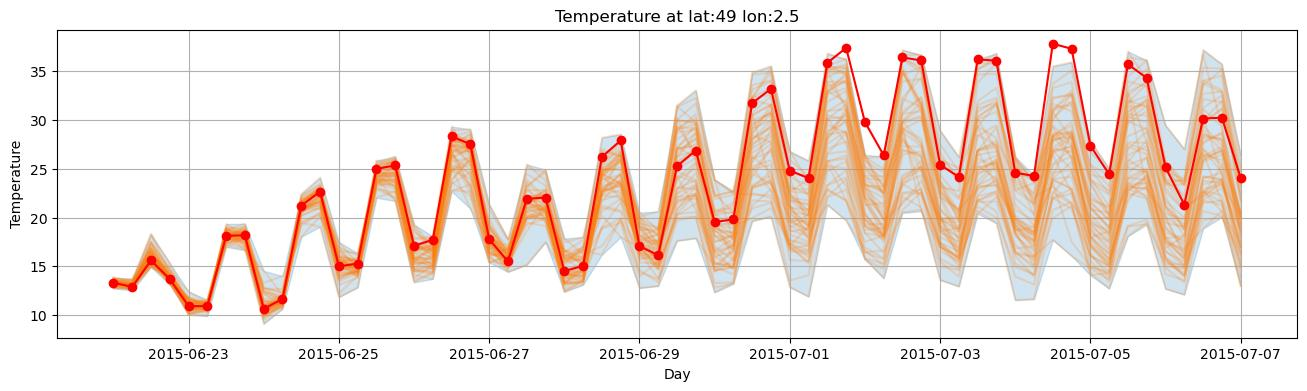

In [14]:
plot_trajectories_on_single_point(
    cf_20150622, pf_20150622, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

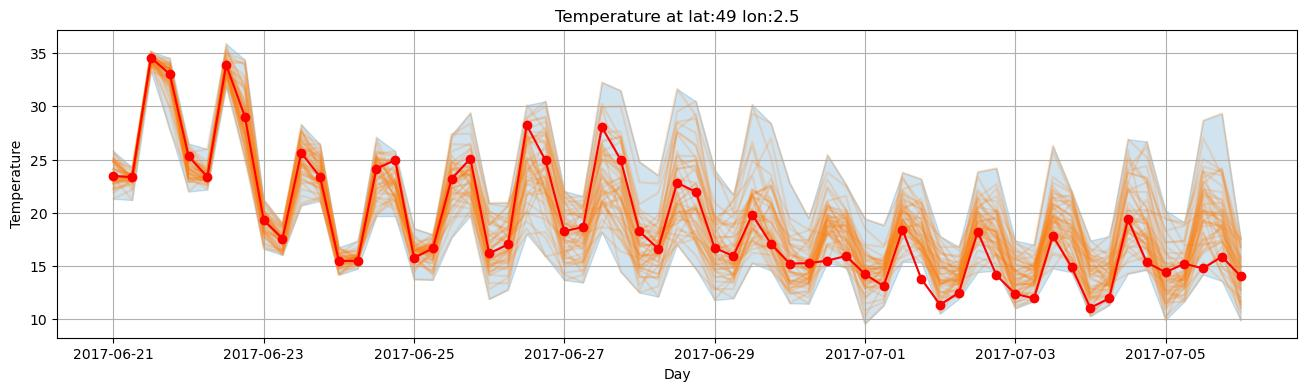

In [15]:
plot_trajectories_on_single_point(
    cf_20170621, pf_20170621, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

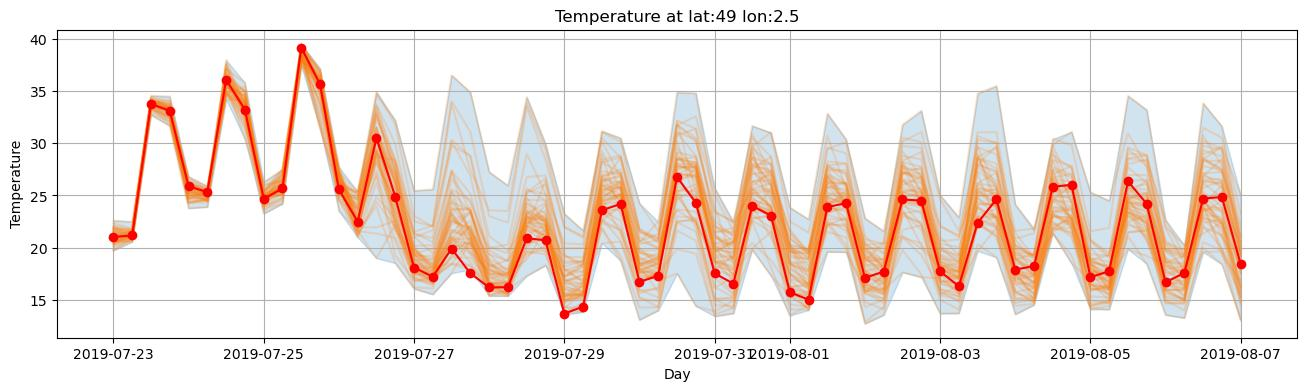

In [16]:
plot_trajectories_on_single_point(
    cf_20190723, pf_20190723, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

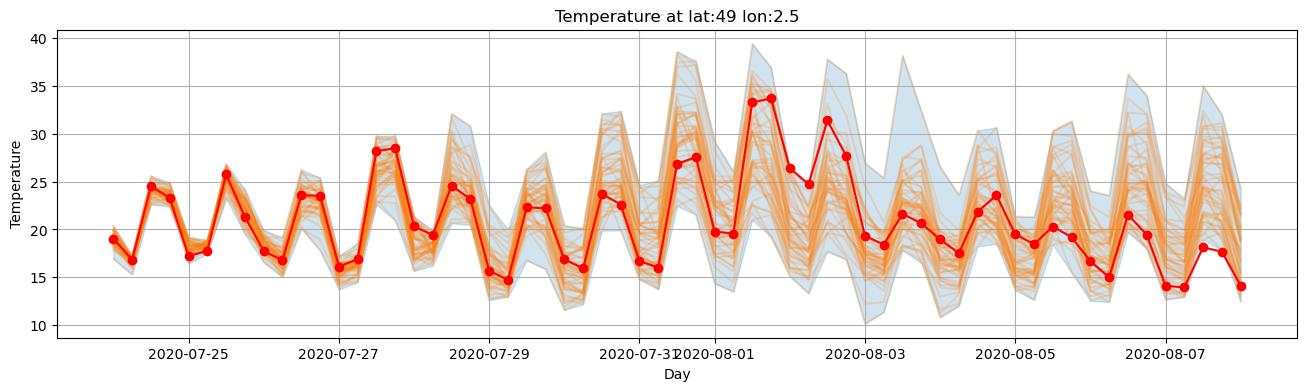

In [17]:
plot_trajectories_on_single_point(
    cf_20200724, pf_20200724, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

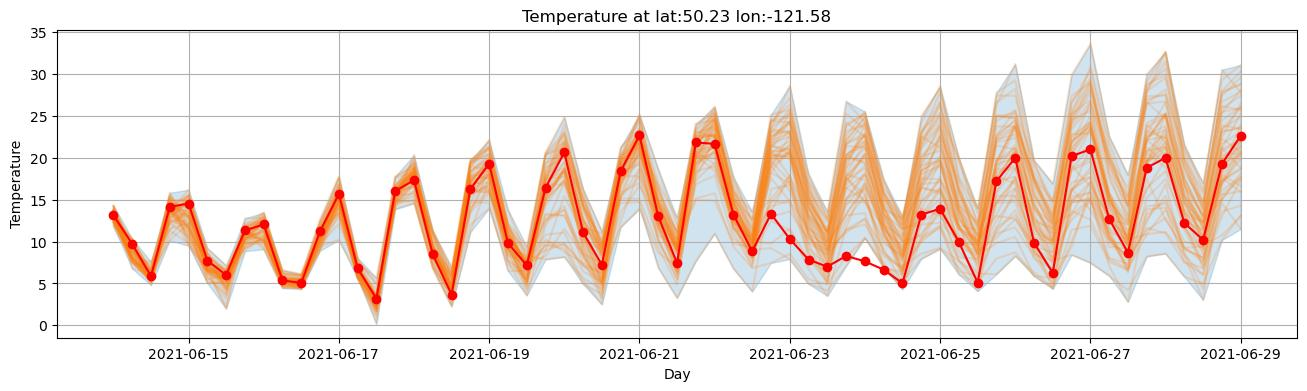

In [18]:
plot_trajectories_on_single_point(
    cf_20210614, pf_20210614, lytton_latitude, lytton_longitude, times=[0, 6, 12, 18]
)

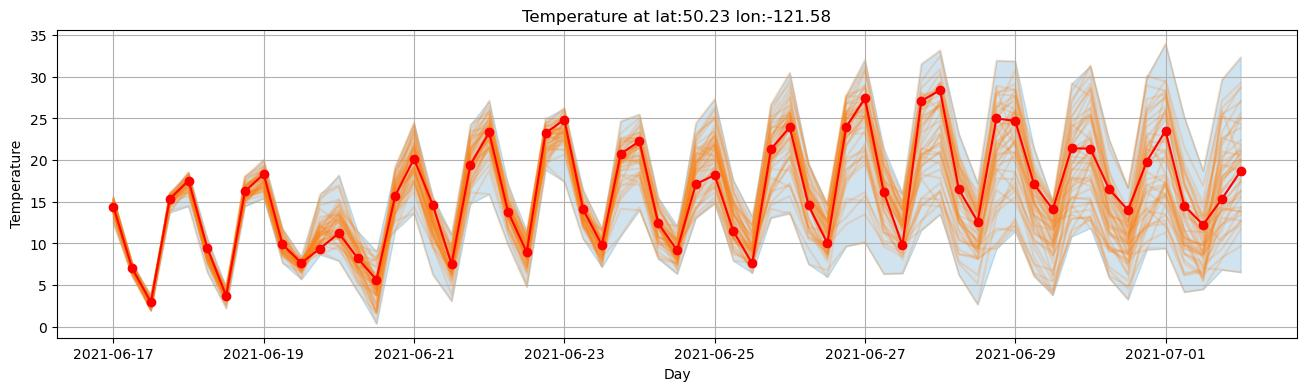

In [19]:
plot_trajectories_on_single_point(
    cf_20210617, pf_20210617, lytton_latitude, lytton_longitude, times=[0, 6, 12, 18]
)

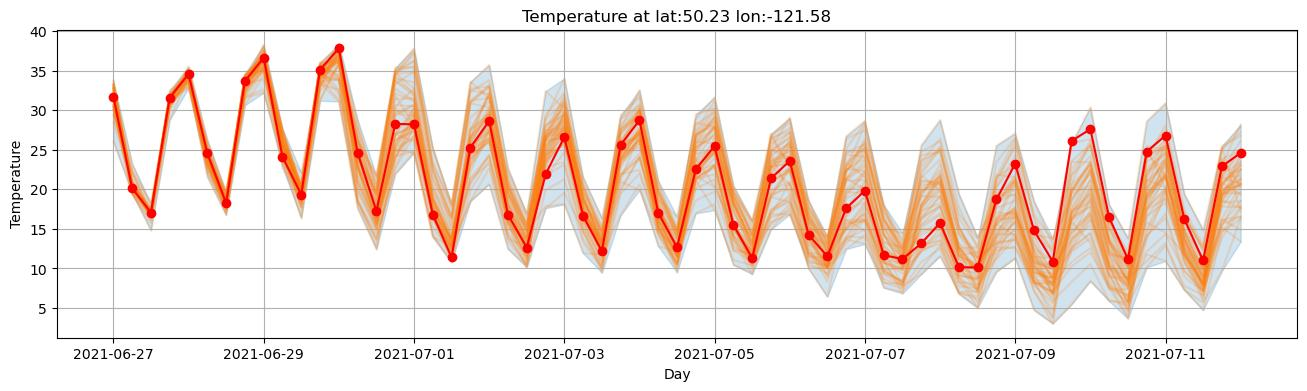

In [20]:
plot_trajectories_on_single_point(
    cf_20210627, pf_20210627, lytton_latitude, lytton_longitude, times=[0, 6, 12, 18]
)

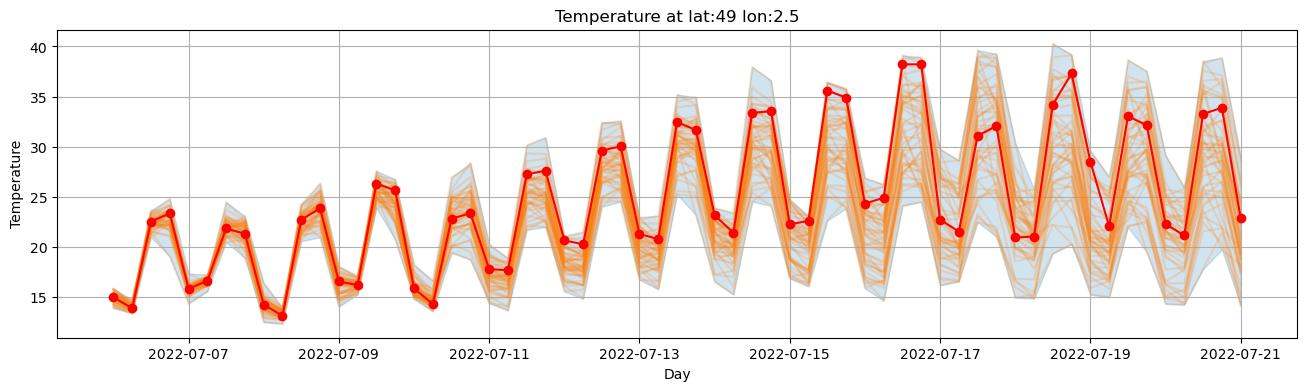

In [21]:
plot_trajectories_on_single_point(
    cf_20220706, pf_20220706, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

#### IFS and AIFS

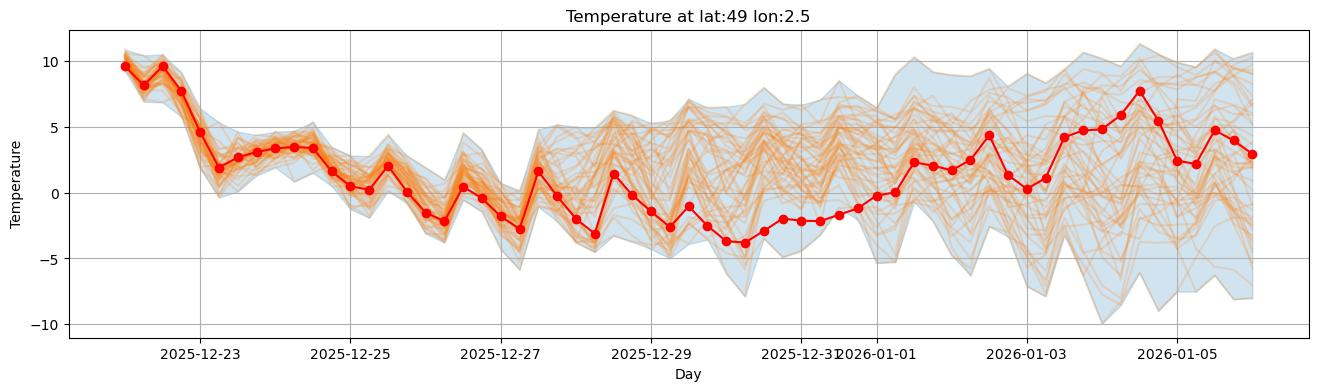

In [22]:
plot_trajectories_on_single_point(
    cf_aifs_cold_spell_2025,
    pf_aifs_cold_spell_2025,
    paris_latitude,
    paris_longitude,
    times=[0, 6, 12, 18],
)

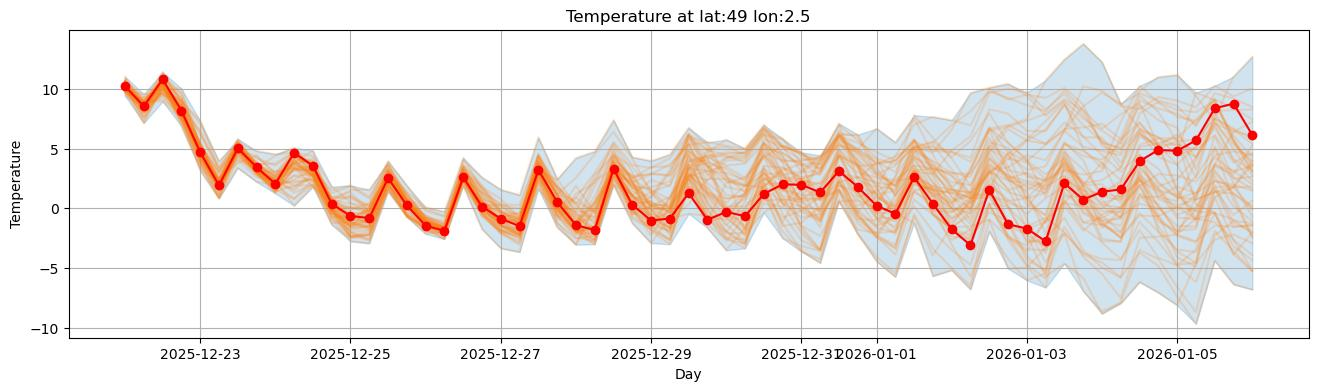

In [23]:
plot_trajectories_on_single_point(
    cf_20251222, pf_20251222, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

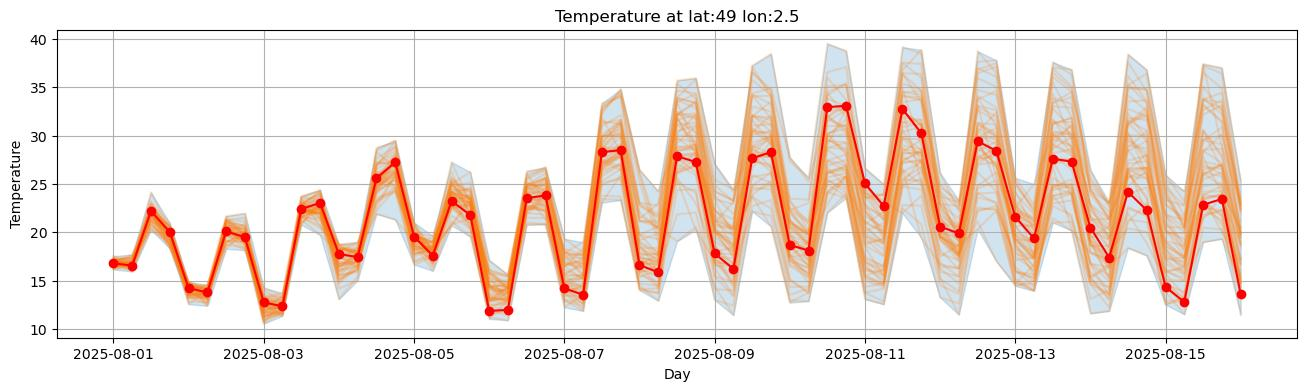

In [24]:
plot_trajectories_on_single_point(
    cf_aifs_heat_august_2025,
    pf_aifs_heat_august_2025,
    paris_latitude,
    paris_longitude,
    times=[0, 6, 12, 18],
)

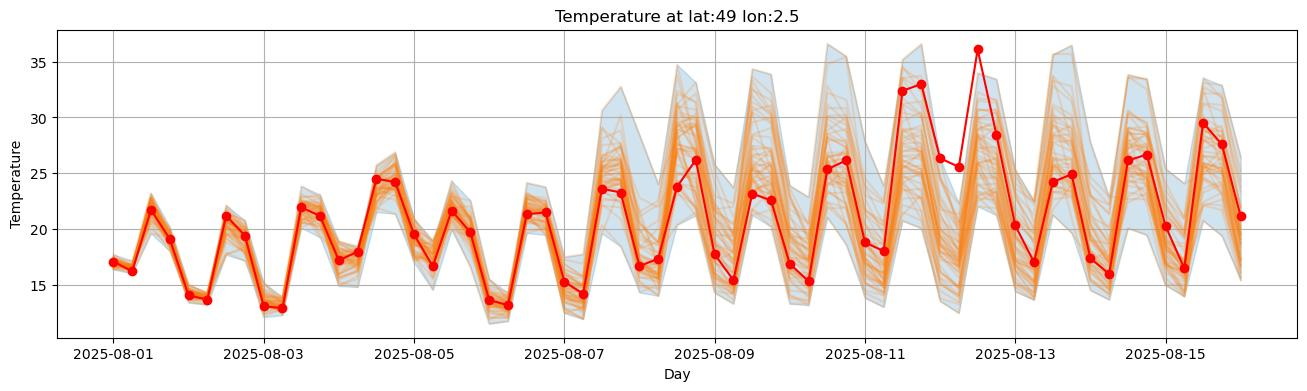

In [25]:
plot_trajectories_on_single_point(
    cf_20250801, pf_20250801, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

### Over an area

#### Only IFS

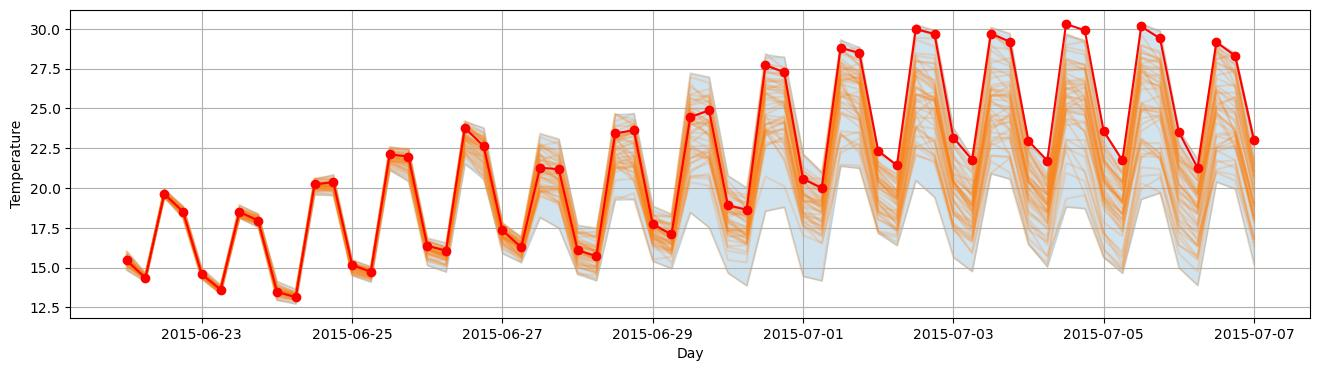

In [26]:
plot_trajectories_on_area_mean(
    cf_20150622,
    pf_20150622,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

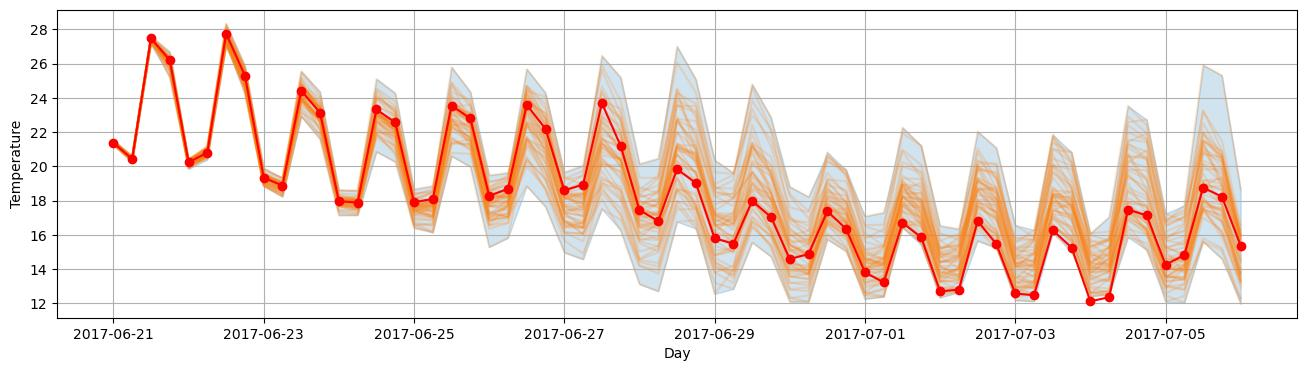

In [27]:
plot_trajectories_on_area_mean(
    cf_20170621,
    pf_20170621,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

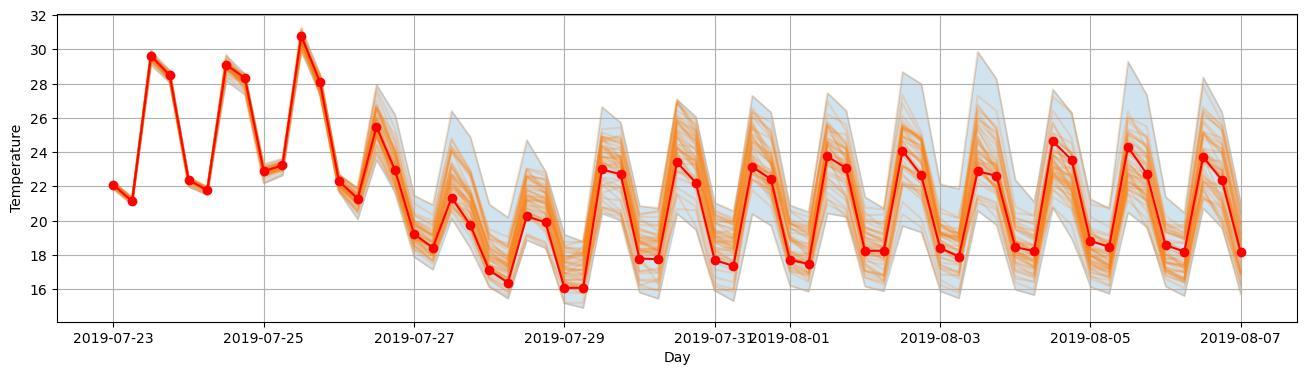

In [28]:
plot_trajectories_on_area_mean(
    cf_20190723,
    pf_20190723,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

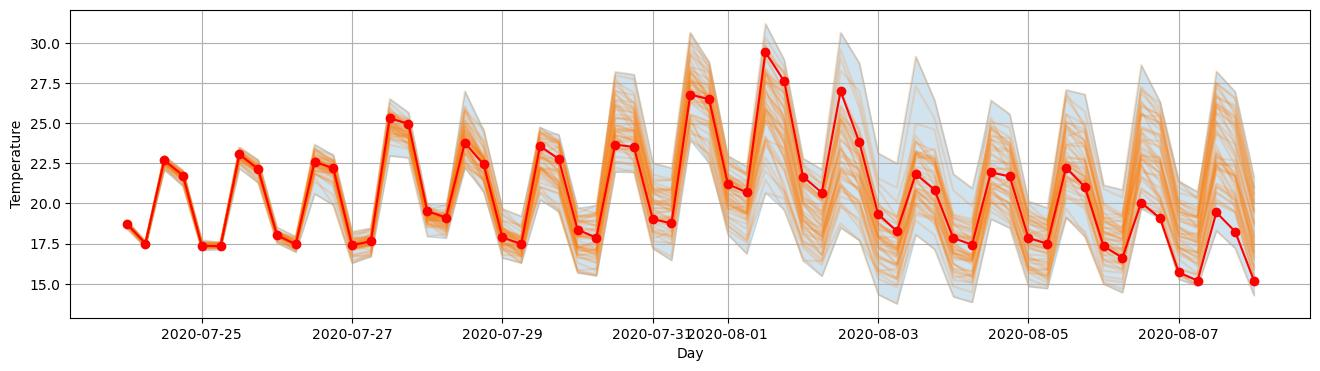

In [29]:
plot_trajectories_on_area_mean(
    cf_20200724,
    pf_20200724,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

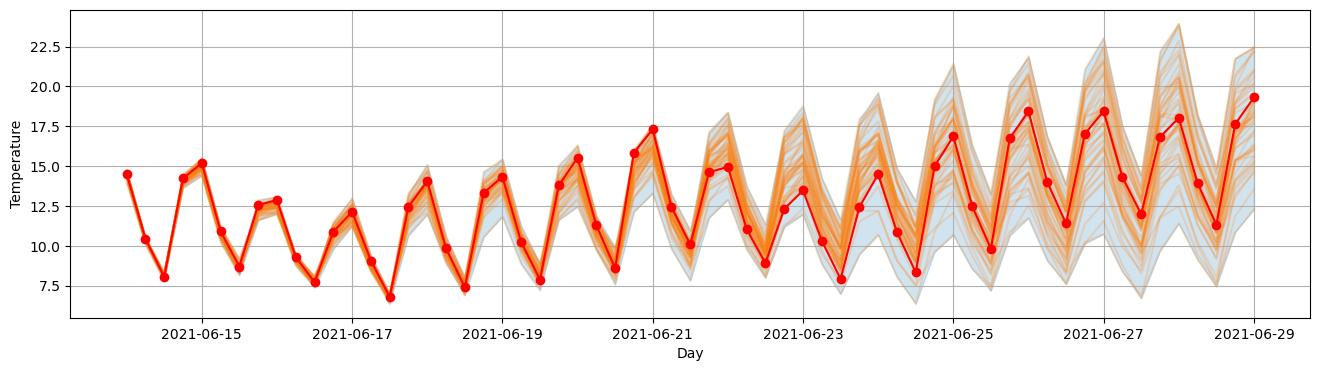

In [30]:
plot_trajectories_on_area_mean(
    cf_20210614, pf_20210614, bc_latitude_bnd, bc_longitude_bnd, times=[0, 6, 12, 18]
)

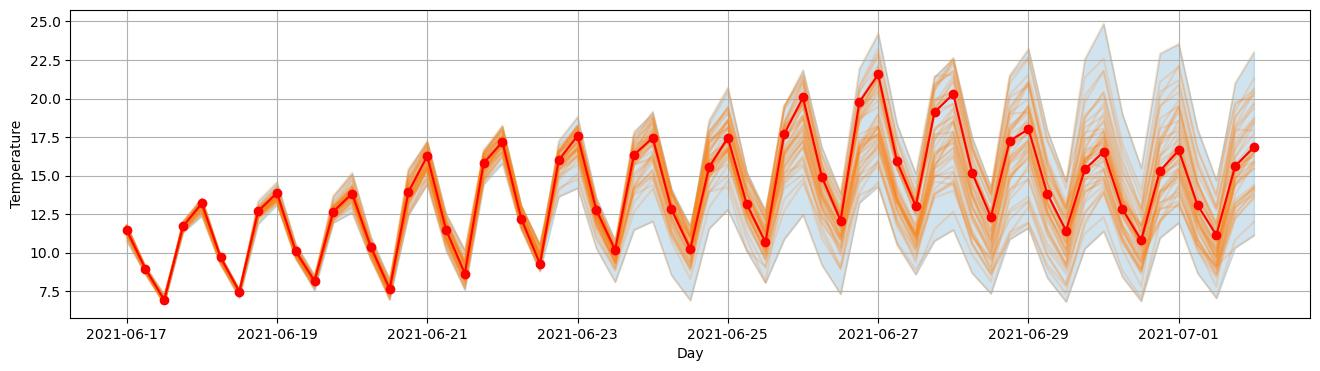

In [31]:
plot_trajectories_on_area_mean(
    cf_20210617, pf_20210617, bc_latitude_bnd, bc_longitude_bnd, times=[0, 6, 12, 18]
)

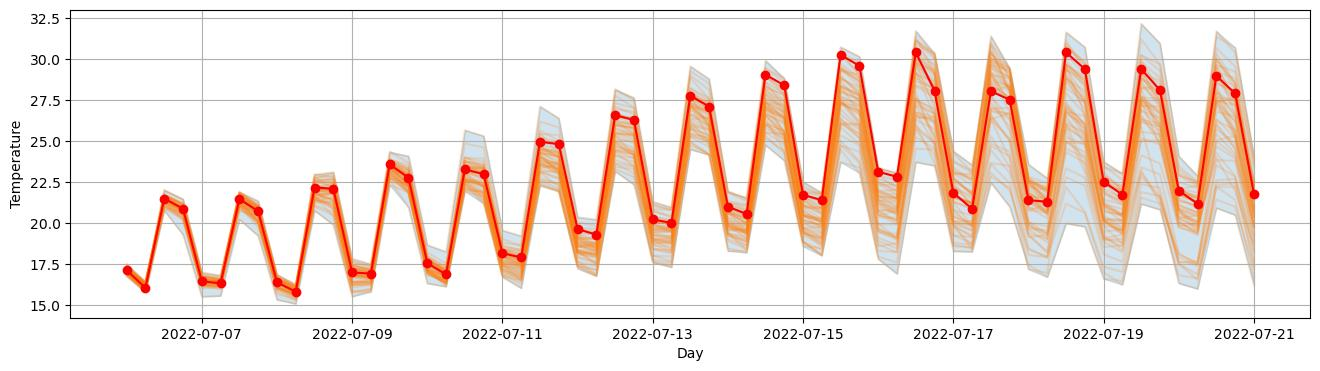

In [32]:
plot_trajectories_on_area_mean(
    cf_20220706,
    pf_20220706,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

#### IFS and AIFS

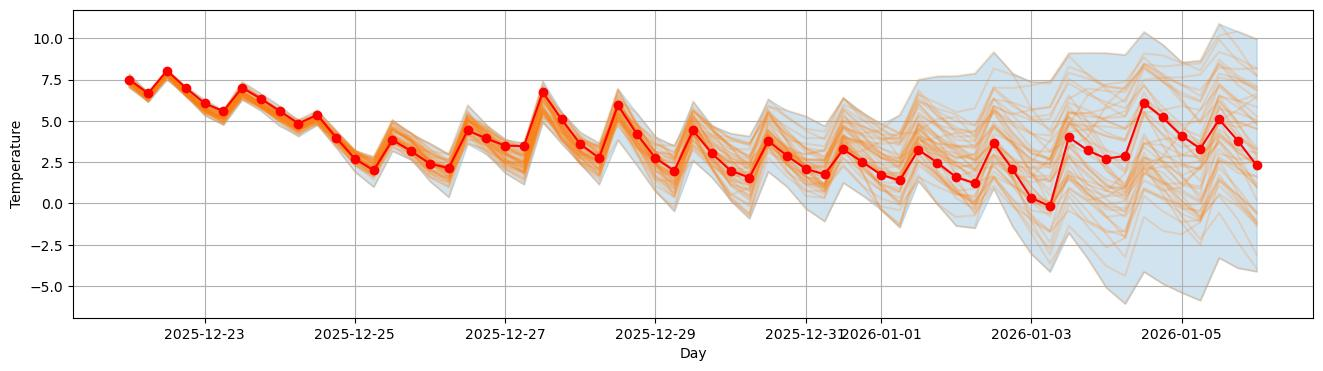

In [33]:
plot_trajectories_on_area_mean(
    cf_aifs_cold_spell_2025,
    pf_aifs_cold_spell_2025,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

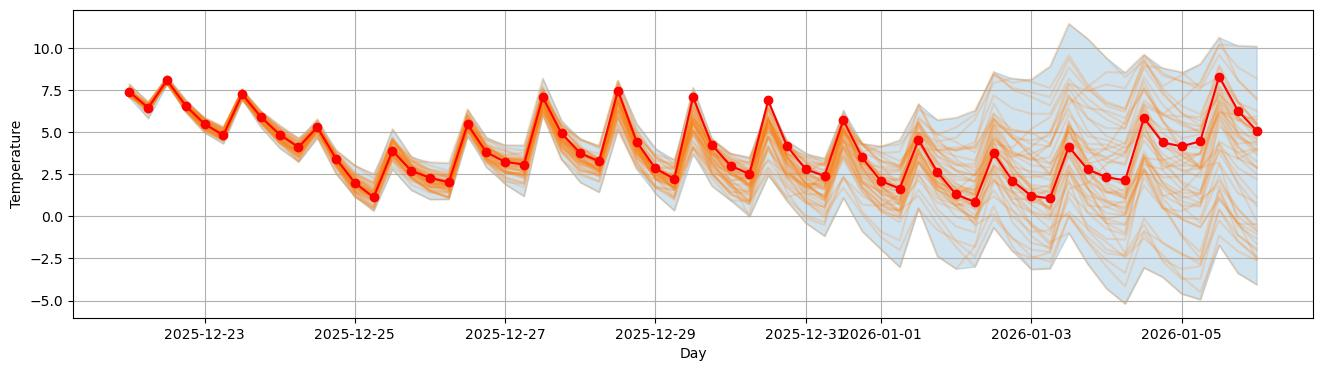

In [34]:
plot_trajectories_on_area_mean(
    cf_20251222,
    pf_20251222,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

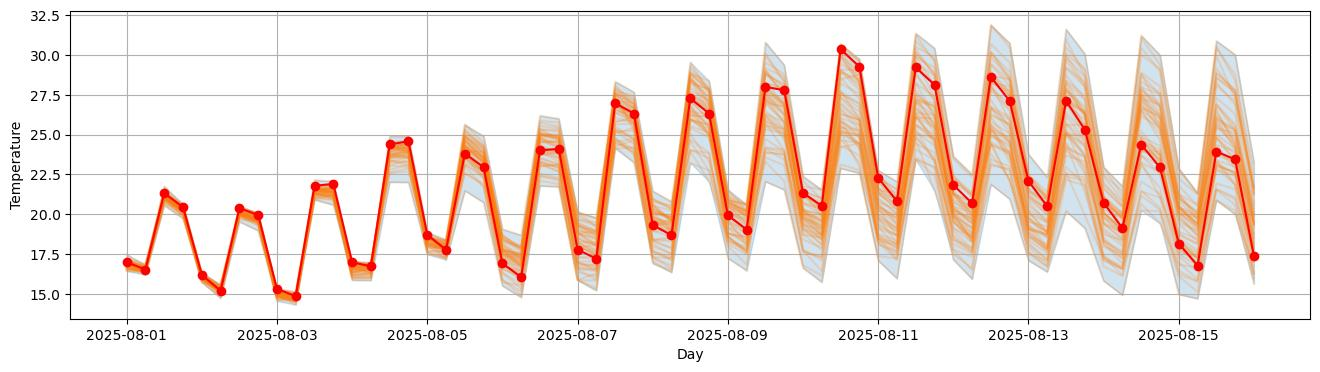

In [35]:
plot_trajectories_on_area_mean(
    cf_aifs_heat_august_2025,
    pf_aifs_heat_august_2025,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

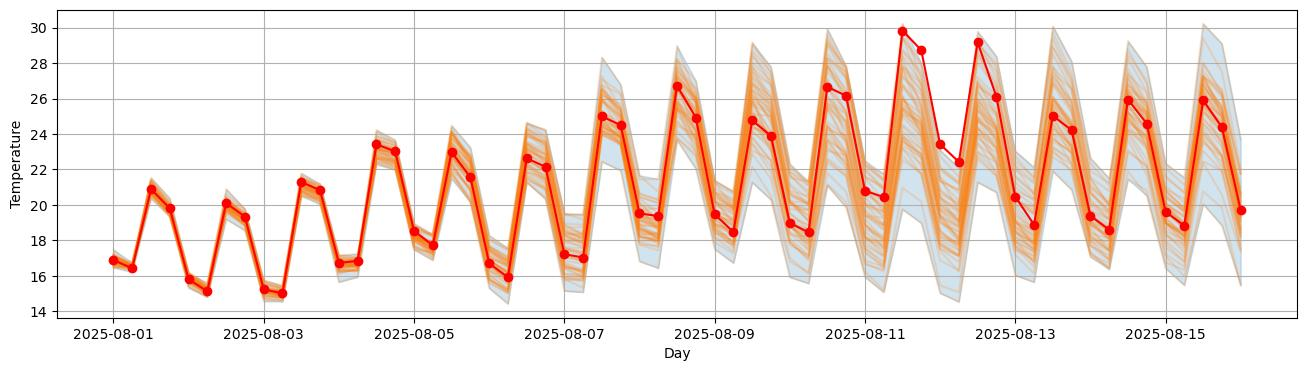

In [36]:
plot_trajectories_on_area_mean(
    cf_20250801,
    pf_20250801,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

## Compute Lyapunov Exponents

### At a single point

#### Only IFS

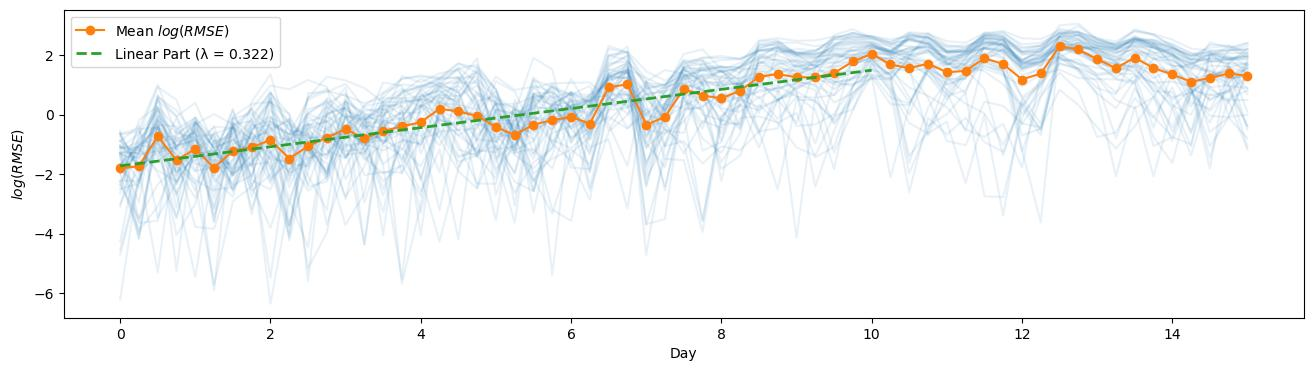

Estimated Lyapunov Exponent (λ): 0.322 days^-1


In [37]:
lyapunov_single_point(
    cf_20150622, pf_20150622, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

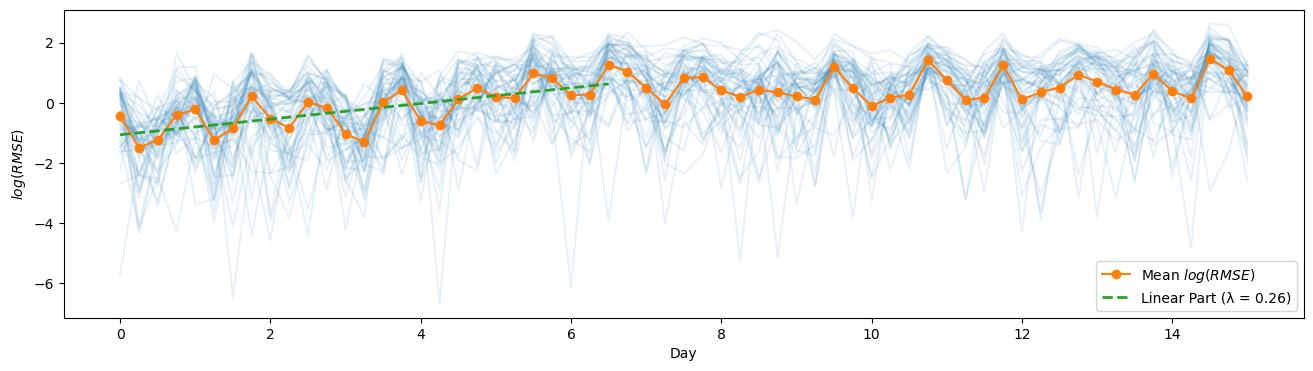

Estimated Lyapunov Exponent (λ): 0.26 days^-1


In [38]:
lyapunov_single_point(
    cf_20170621, pf_20170621, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

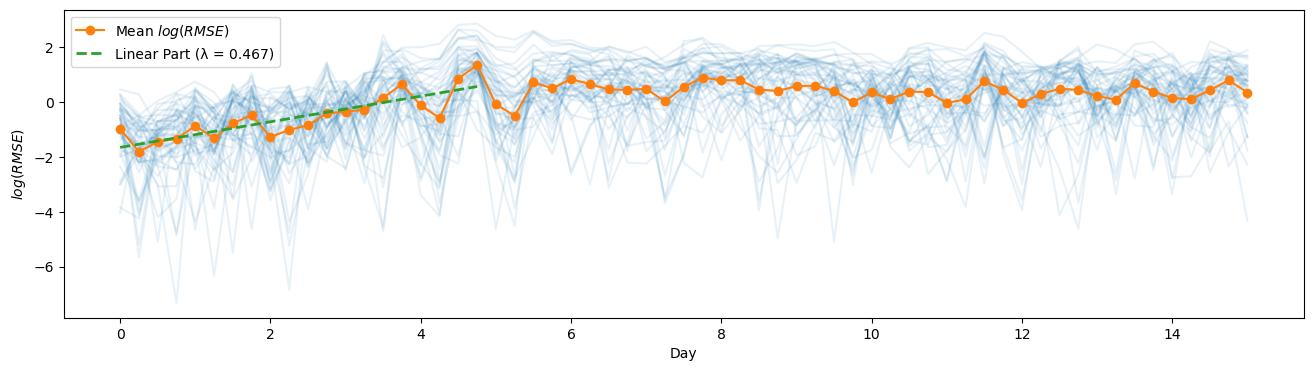

Estimated Lyapunov Exponent (λ): 0.467 days^-1


In [39]:
lyapunov_single_point(
    cf_20190723, pf_20190723, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

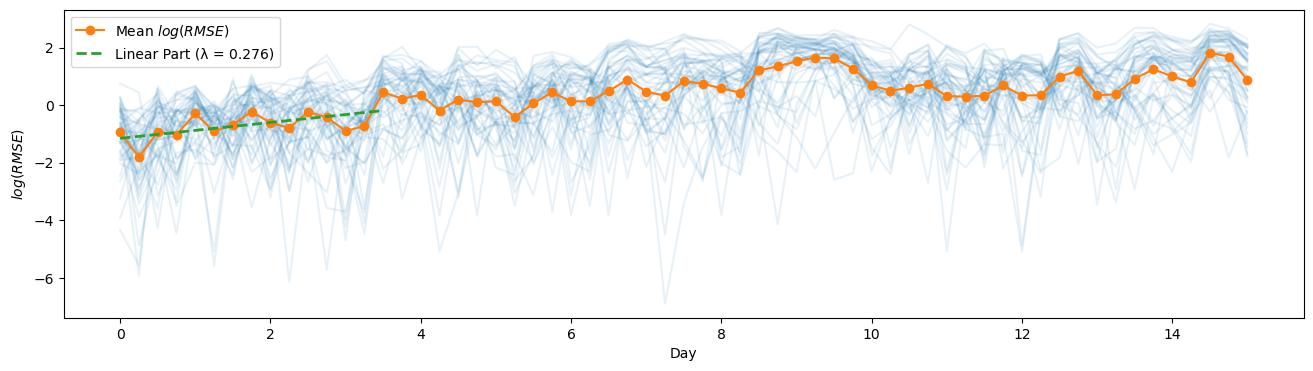

Estimated Lyapunov Exponent (λ): 0.276 days^-1


In [40]:
lyapunov_single_point(
    cf_20200724, pf_20200724, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

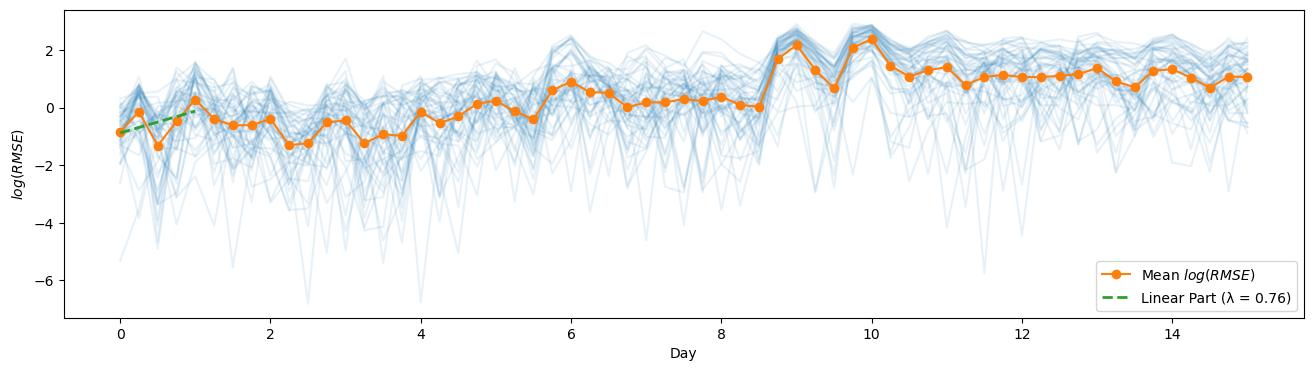

Estimated Lyapunov Exponent (λ): 0.76 days^-1


In [41]:
lyapunov_single_point(
    cf_20210614, pf_20210614, lytton_latitude, lytton_longitude, times=[0, 6, 12, 18]
)

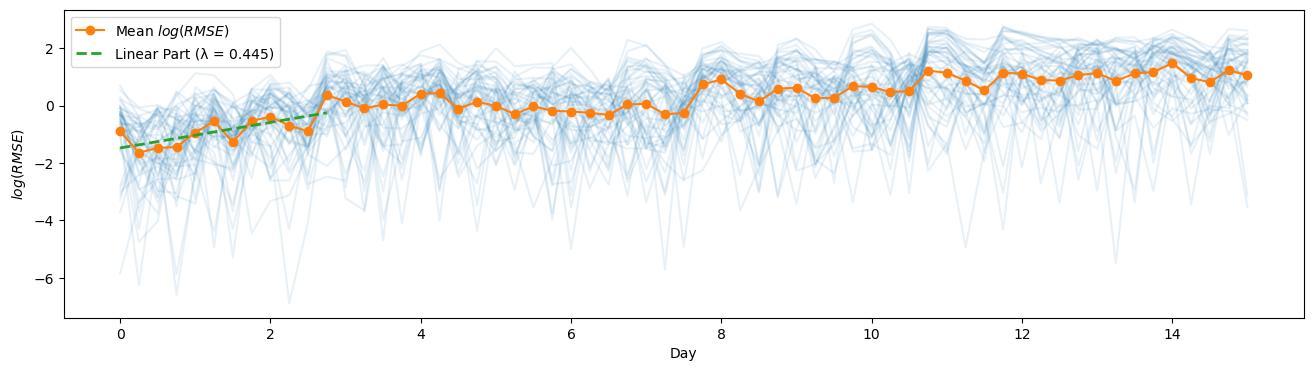

Estimated Lyapunov Exponent (λ): 0.445 days^-1


In [42]:
lyapunov_single_point(
    cf_20210617, pf_20210617, lytton_latitude, lytton_longitude, times=[0, 6, 12, 18]
)

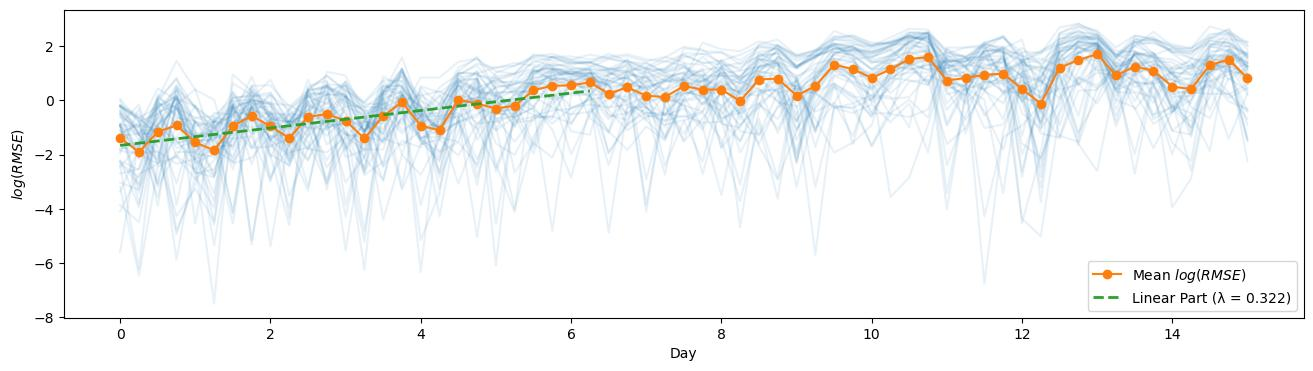

Estimated Lyapunov Exponent (λ): 0.322 days^-1


In [43]:
lyapunov_single_point(
    cf_20220706, pf_20220706, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

#### IFS and AIFS

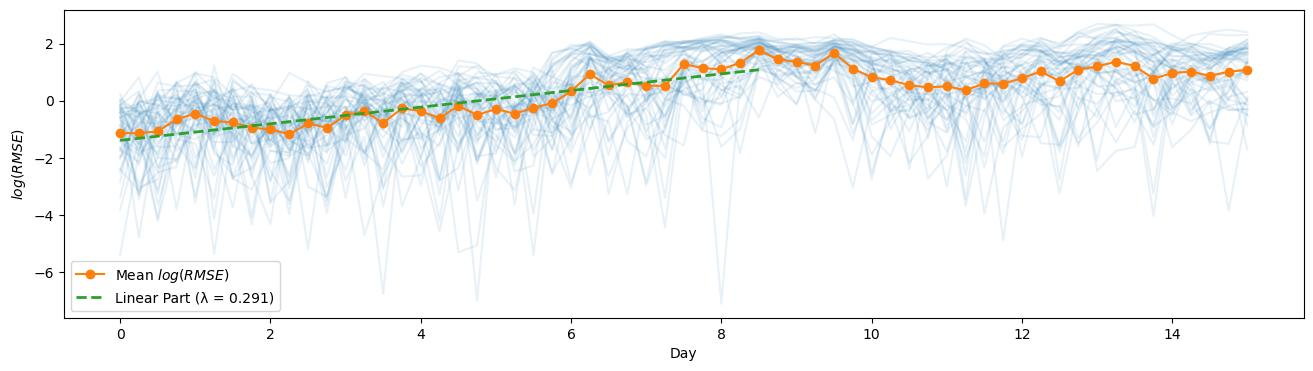

Estimated Lyapunov Exponent (λ): 0.291 days^-1


In [44]:
lyapunov_single_point(
    cf_aifs_cold_spell_2025,
    pf_aifs_cold_spell_2025,
    paris_latitude,
    paris_longitude,
    times=[0, 6, 12, 18],
)

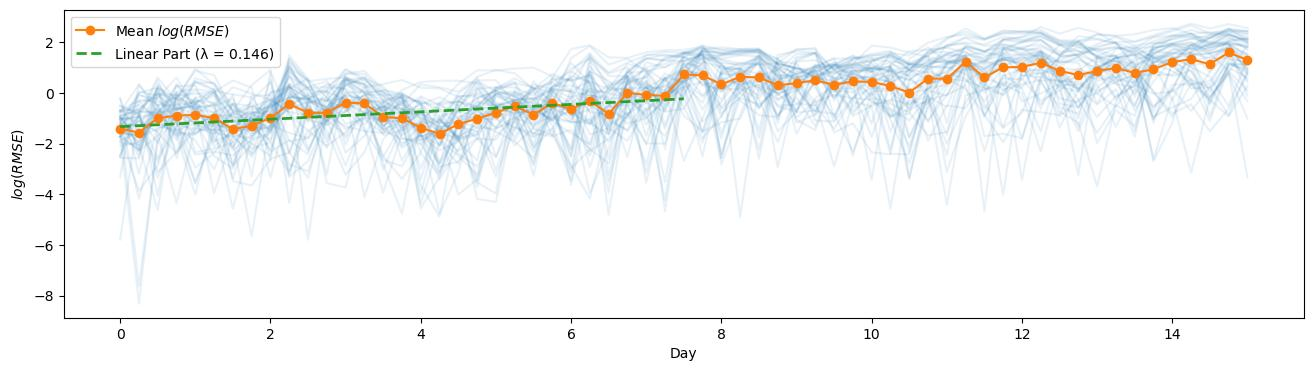

Estimated Lyapunov Exponent (λ): 0.146 days^-1


In [45]:
lyapunov_single_point(
    cf_20251222, pf_20251222, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

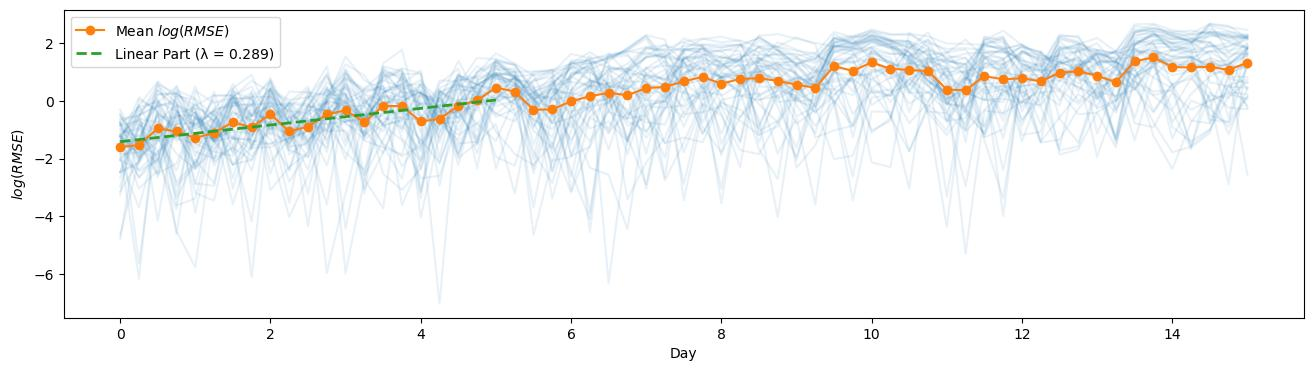

Estimated Lyapunov Exponent (λ): 0.289 days^-1


In [46]:
lyapunov_single_point(
    cf_aifs_heat_august_2025,
    pf_aifs_heat_august_2025,
    paris_latitude,
    paris_longitude,
    times=[0, 6, 12, 18],
)

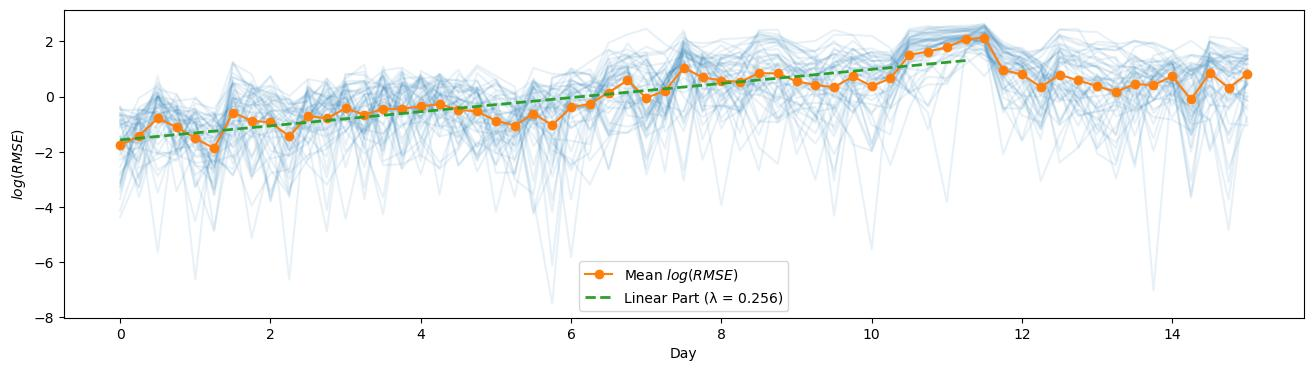

Estimated Lyapunov Exponent (λ): 0.256 days^-1


In [47]:
lyapunov_single_point(
    cf_20250801, pf_20250801, paris_latitude, paris_longitude, times=[0, 6, 12, 18]
)

### Over an area

#### Only IFS

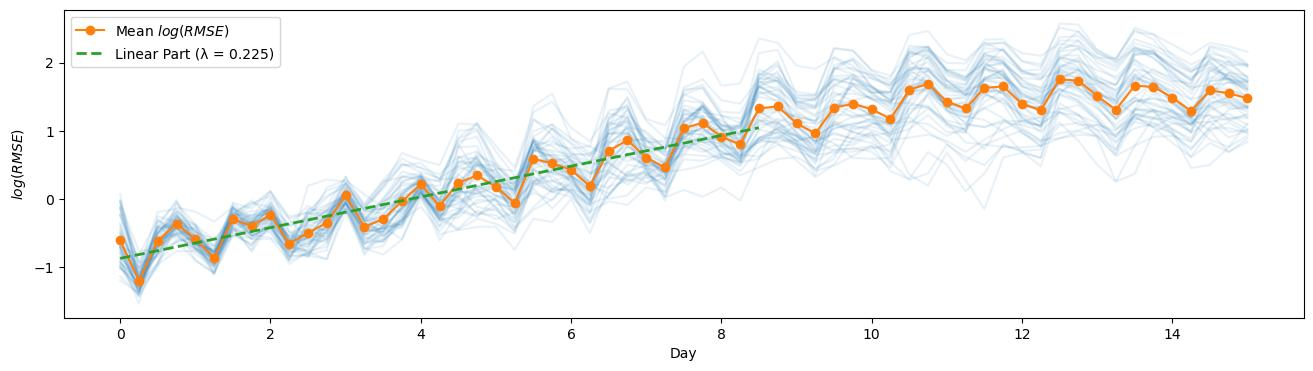

Estimated Lyapunov Exponent (λ): 0.225 days^-1


np.float64(0.225)

In [48]:
lyapunov_over_area(
    cf_20150622,
    pf_20150622,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

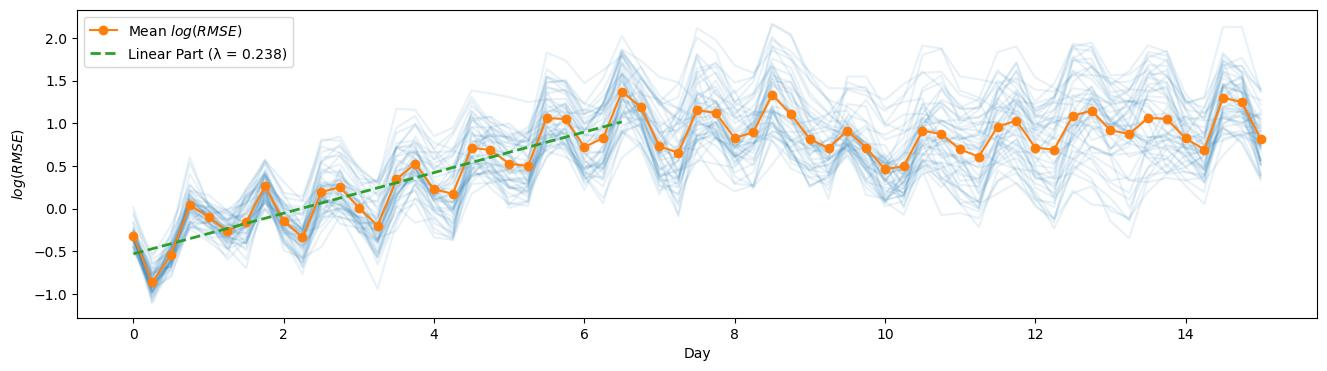

Estimated Lyapunov Exponent (λ): 0.238 days^-1


np.float64(0.238)

In [49]:
lyapunov_over_area(
    cf_20170621,
    pf_20170621,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

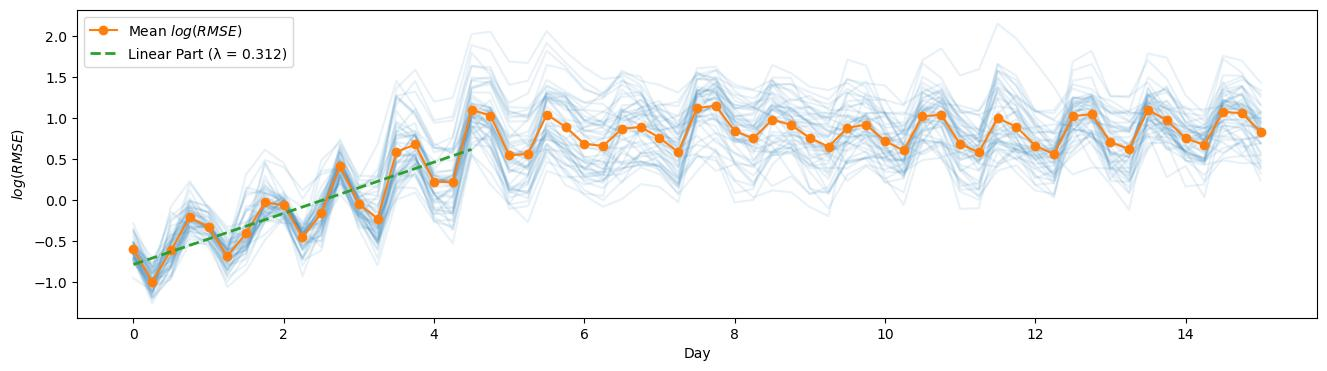

Estimated Lyapunov Exponent (λ): 0.312 days^-1


np.float64(0.312)

In [50]:
lyapunov_over_area(
    cf_20190723,
    pf_20190723,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

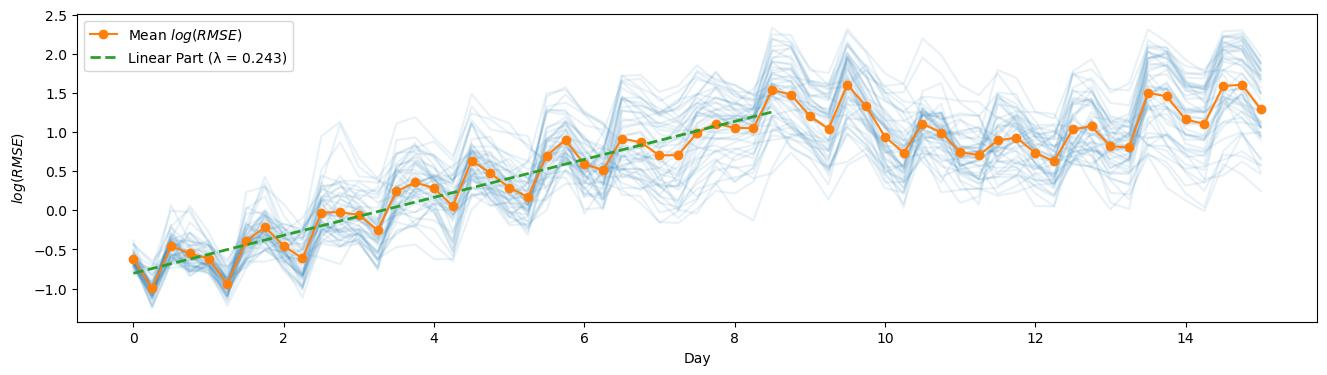

Estimated Lyapunov Exponent (λ): 0.243 days^-1


np.float64(0.243)

In [51]:
lyapunov_over_area(
    cf_20200724,
    pf_20200724,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

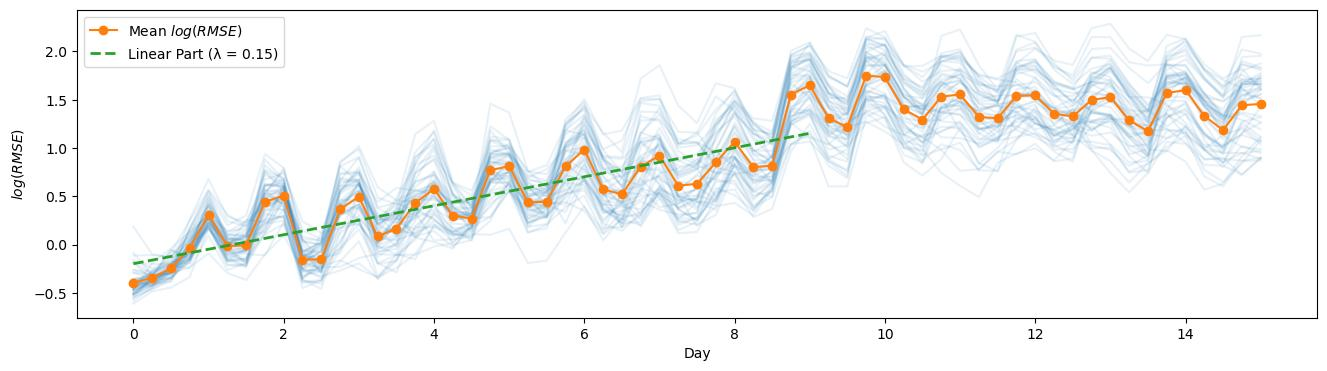

Estimated Lyapunov Exponent (λ): 0.15 days^-1


np.float64(0.15)

In [52]:
lyapunov_over_area(
    cf_20210614, pf_20210614, bc_latitude_bnd, bc_longitude_bnd, times=[0, 6, 12, 18]
)

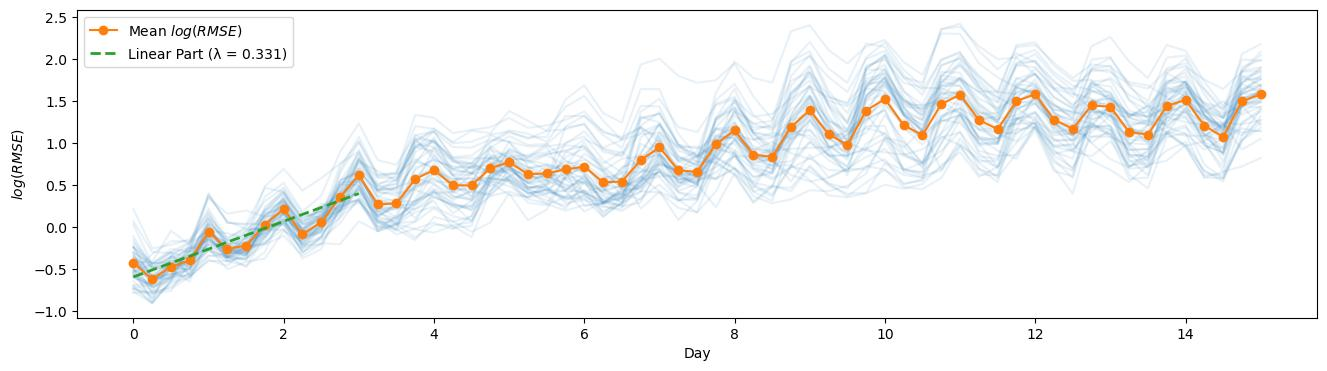

Estimated Lyapunov Exponent (λ): 0.331 days^-1


np.float64(0.331)

In [53]:
lyapunov_over_area(
    cf_20210617, pf_20210617, bc_latitude_bnd, bc_longitude_bnd, times=[0, 6, 12, 18]
)

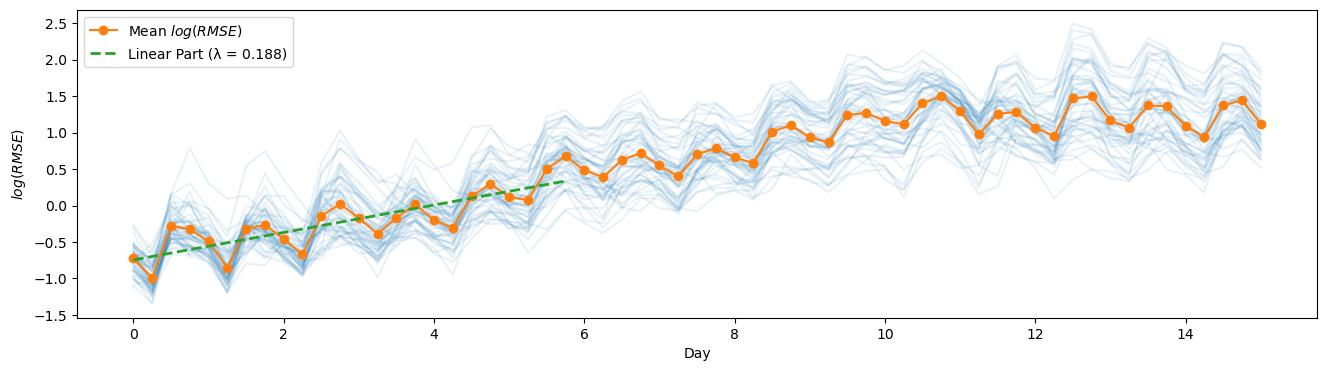

Estimated Lyapunov Exponent (λ): 0.188 days^-1


np.float64(0.188)

In [54]:
lyapunov_over_area(
    cf_20220706,
    pf_20220706,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

#### IFS and AIFS

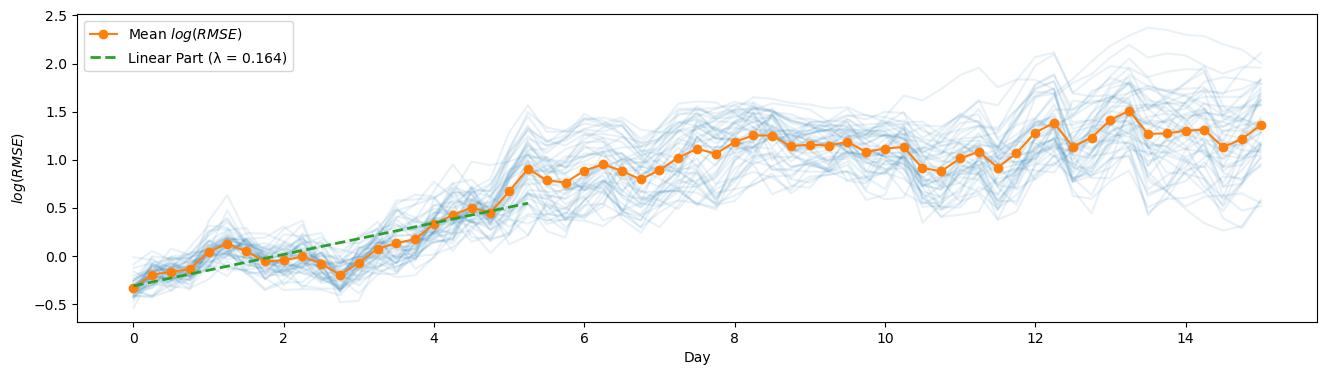

Estimated Lyapunov Exponent (λ): 0.164 days^-1


np.float64(0.164)

In [55]:
lyapunov_over_area(
    cf_aifs_cold_spell_2025,
    pf_aifs_cold_spell_2025,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

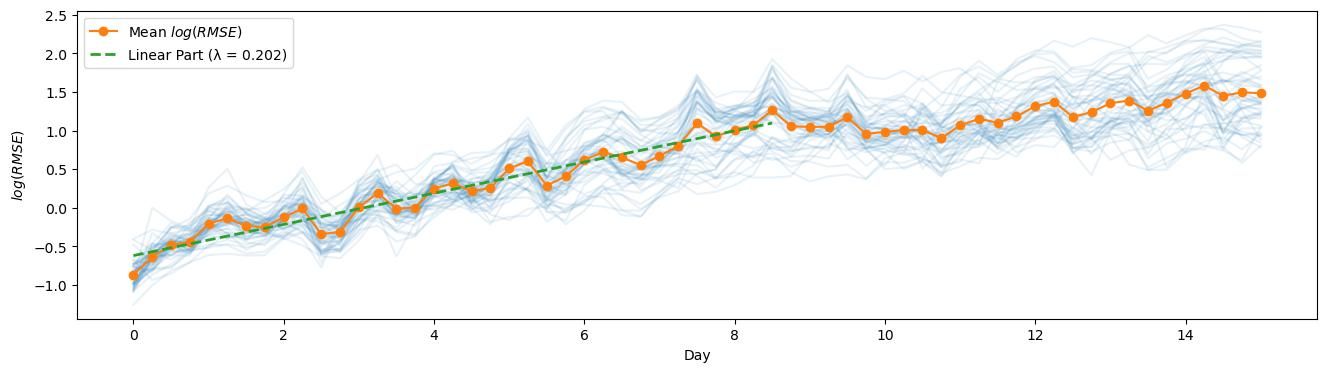

Estimated Lyapunov Exponent (λ): 0.202 days^-1


np.float64(0.202)

In [56]:
lyapunov_over_area(
    cf_20251222,
    pf_20251222,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

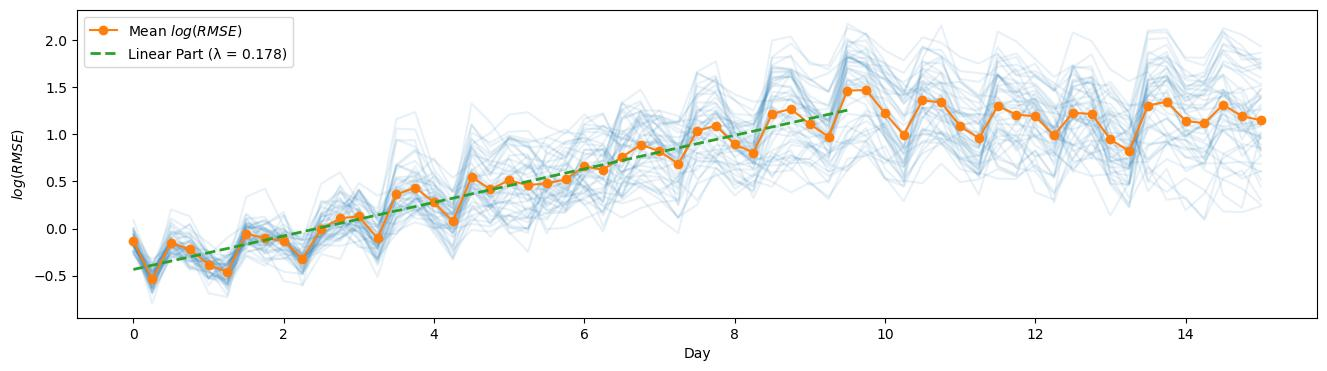

Estimated Lyapunov Exponent (λ): 0.178 days^-1


np.float64(0.178)

In [57]:
lyapunov_over_area(
    cf_aifs_heat_august_2025,
    pf_aifs_heat_august_2025,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

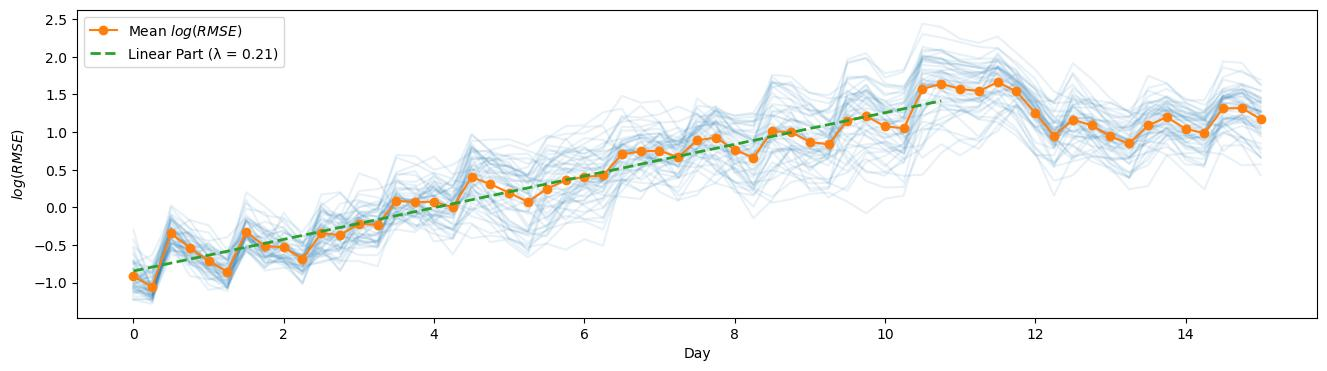

Estimated Lyapunov Exponent (λ): 0.21 days^-1


np.float64(0.21)

In [58]:
lyapunov_over_area(
    cf_20250801,
    pf_20250801,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

In [59]:
import bottleneck as bn

In [60]:
bn.move_mean

<function bottleneck.move.move_mean>

#### IFS and AIFS but pairwise

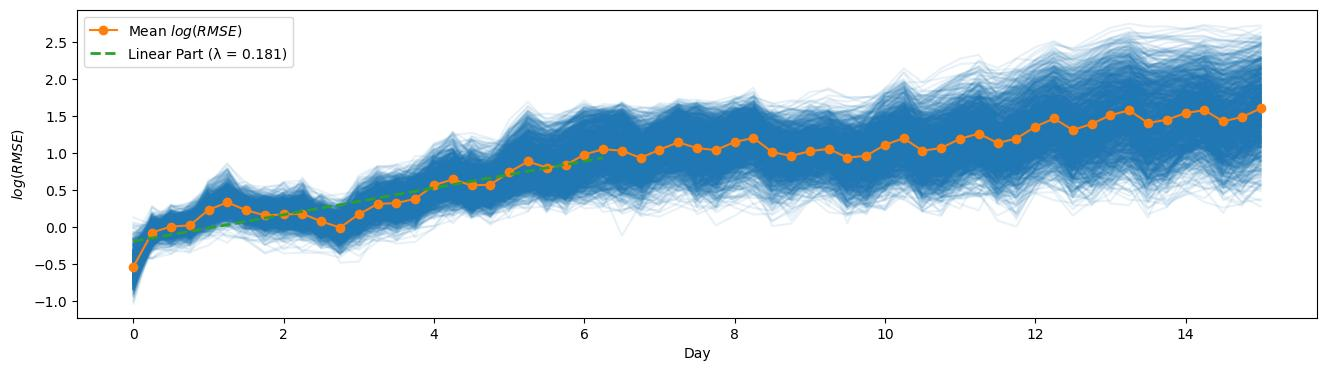

Estimated Lyapunov Exponent (λ): 0.181 days^-1


np.float64(0.181)

In [61]:
lyapunov_over_area_pairwise(
    cf_aifs_cold_spell_2025,
    pf_aifs_cold_spell_2025,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

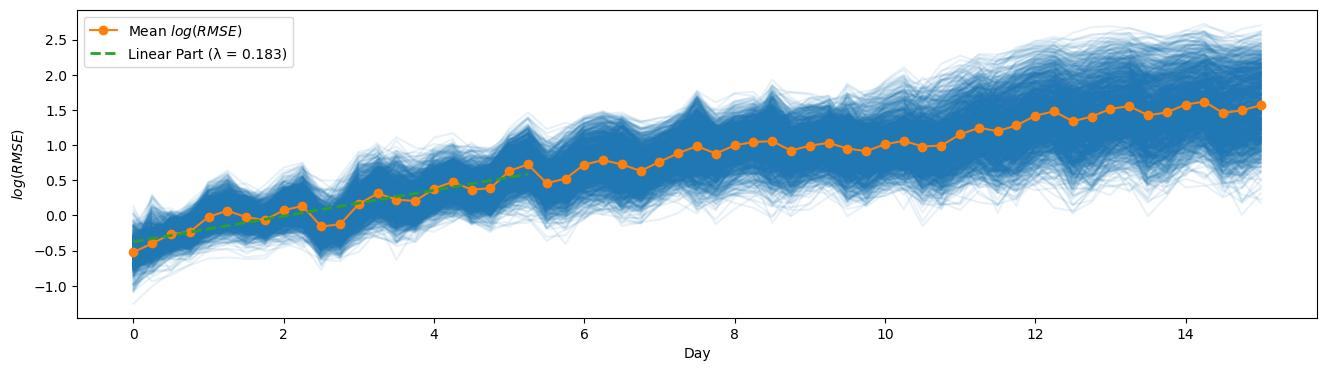

Estimated Lyapunov Exponent (λ): 0.183 days^-1


np.float64(0.183)

In [62]:
lyapunov_over_area_pairwise(
    cf_20251222,
    pf_20251222,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

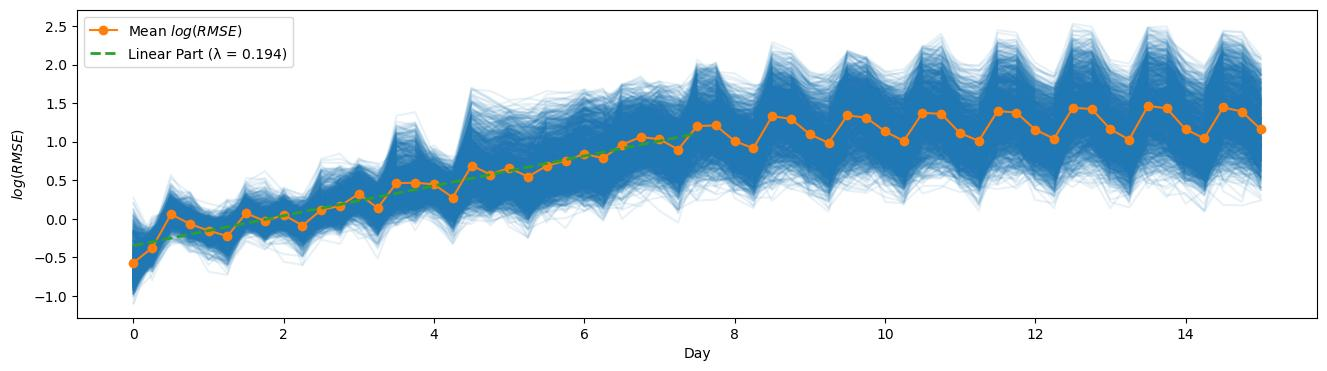

Estimated Lyapunov Exponent (λ): 0.194 days^-1


np.float64(0.194)

In [63]:
lyapunov_over_area_pairwise(
    cf_aifs_heat_august_2025,
    pf_aifs_heat_august_2025,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

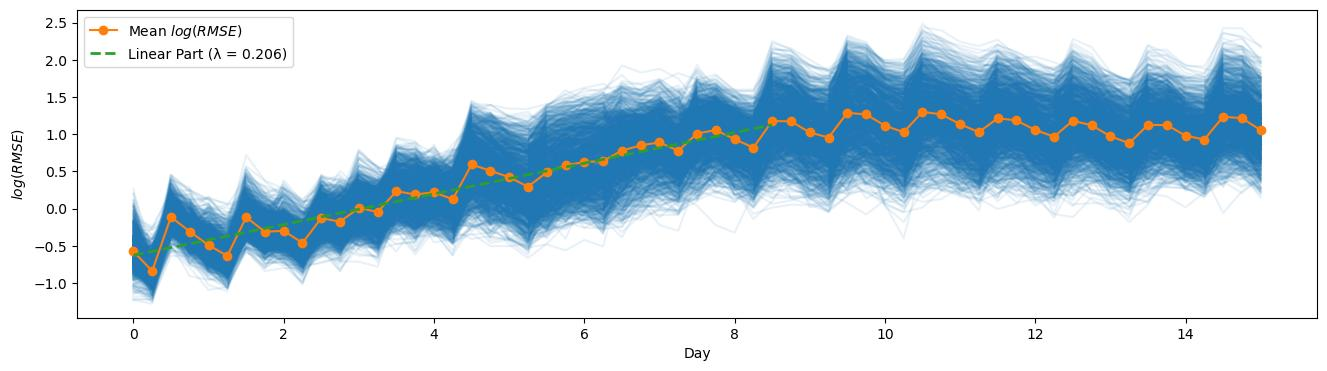

Estimated Lyapunov Exponent (λ): 0.206 days^-1


np.float64(0.206)

In [64]:
lyapunov_over_area_pairwise(
    cf_20250801,
    pf_20250801,
    france_latitude_bnd,
    france_longitude_bnd,
    times=[0, 6, 12, 18],
)

# Plot some maps

In [ ]:
plot_nice_looking_animation(cf_20210617.t2m, bc_latitude_bnd, bc_longitude_bnd)

In [ ]:
plot_nice_looking_animation_ortho(cf_20210617.t2m, bc_latitude_bnd, bc_longitude_bnd)